# Between-scanner, within-scanner and between-paradigm variability of FC matrices

In [1]:
library(reticulate)
library(tidyr)
library(MANOVA.RM)
library(irr)
library(effectsize)
library(ggplot2)
library(ggbeeswarm)
library(dplyr)
library(patchwork)
library(FSA)
use_python("/home/cprovins/miniconda3/envs/pymc_env/bin/python", required = TRUE)

Loading required package: lpSolve


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


## FSA v0.10.0. See citation('FSA') if used in publication.
## Run fishR() for related website and fishR('IFAR') for related book.



## Load the FC matrices

We load the functional connectivity (FC) matrices using Python code so we can conveniently leverage our custom configuration for PyBIDS. Which scanner was the participant scanned on during the generalization sessions is encoded in the last three digits of the session number (Prisma=060, Vida=034, VidaFit=030). For the investigation of the paradigm influence, we keep only the generalization sessions using the Prisma scanner.

In [2]:
py_run_string('
import re
import pandas as pd
from pathlib import Path
from bids.layout import BIDSLayout, BIDSLayoutIndexer, add_config_paths
from confounds import get_confounds

# Define filtering parameters
metric = "sparseinversecovariance"
atlas_dimension = "64"
fd_threshold = 0.5
fdthresh_str = str(fd_threshold).replace(".", "")

# Define paths
code_path = Path("/data/code/hcph-sops/")
fc_path = Path(f"/data/derivatives/hcph-fc")
dataset_path = Path("/data/datasets/hcph-dataset")
iqms_path = Path("/data/derivatives/hcph-mriqc/group_bold.tsv")
confounds_path = dataset_path / "phenotype" / "mood_env_quest.tsv"

# Initialize the BIDS layout
config_path = code_path / "code/bids/indexer.json"
try:
    add_config_paths(hcph=config_path)
except ValueError as e:
    if "Configuration \'hcph\' already exists" in str(e):
        print("Configuration hcph already exists, skipping add_config_paths.")
    else:
        raise e

_indexer = BIDSLayoutIndexer(
    config_filename=config_path,
    index_metadata=False,
    validate=False,
)

# Define entities common to all files
entities_base = {
    "subject": "001",
    "measure": metric,
    "scale": atlas_dimension,
    "fd_threshold": fdthresh_str,
}
')

In [3]:
py_run_string('
layout = BIDSLayout(fc_path, config="hcph", indexer=_indexer, validate=False)

## Load FC matrices for the generalization sessions
entities_base_gen = {
    **entities_base,
    "task": "rest",
}
# Get functional connectivity files
files_gen = layout.get(**entities_base_gen, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_gen) == 36, f"Expected 36 FC matrices, got {len(files_gen)}"
df_fc = pd.DataFrame({"filename": files_gen, "subject": "001"})

# Retrieve which scanner was used for each session (encoded in the last three digits of the session ID)
df_fc["session"] = df_fc["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)

def extract_scanner(session):
    scanner_codes = {"060": "prisma", "034": "vida", "030": "vidafit"}
    code = session[-3:]
    return scanner_codes.get(code, "unknown")

df_fc["scanner"] = df_fc["session"].apply(extract_scanner)
df_fc["repetition"] = df_fc["session"].str[1:3].astype(int)

## Load confounds
confounds_df = get_confounds(dataset_path, confounds_path, confounds_of_interest=["slept_rest"], iqms_path=iqms_path, iqms_of_interest=["fd_mean"])
# Keep only the magnitude part of functional scans and first echo
confounds_df = confounds_df[confounds_df["modality"] == "func"]
# Keep only the resting-state scans
confounds_df = confounds_df[confounds_df["task"].isin(["rest", "rsmovie"])]
# Drop columns that are not needed here
confounds_df = confounds_df.drop(columns=["filename", "modality", "task", "day_of_week", "time_of_day"])

# Merge the confounds in
df_fc = pd.merge(
        df_fc, confounds_df, on=["subject", "session"], how="inner"
    )

## Load FC matrices from the reliability sessions
entities_base_rel = {
    **entities_base,
    "task": "rsmovie",
}
files_rel = layout.get(**entities_base_rel, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_rel) == 36, f"Expected 36 FC matrices, got {len(files_rel)}"
df_rsmovie = pd.DataFrame({"filename": files_rel, "task": "rsmovie", "subject": "001"})
df_rsmovie["session"] = df_rsmovie["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)
df_rsmovie["repetition"] = df_rsmovie.index + 1
# Merge the confounds in
df_rsmovie = pd.merge(df_rsmovie, confounds_df, on=["subject", "session"], how="inner")

# Keep only the session with prisma scanner for investigation of paradigm influence
df_fc_paradigm = df_fc[df_fc["scanner"] == "prisma"]
df_fc_paradigm = df_fc_paradigm.drop(columns=["scanner"])
df_fc_paradigm["task"] = "rest"
assert len(df_fc_paradigm) == 12, f"Expected 12 FC matrices for prisma scanner, got {len(df_fc_paradigm)}"

## Concatenate the two dataframes
df_fc_paradigm = pd.concat([df_fc_paradigm, df_rsmovie], ignore_index=True)
assert len(df_fc_paradigm) == 48, f"Expected 48 FC matrices after concatenation, got {len(df_fc_paradigm)}"
')

In [4]:
## Helper function to load the FC matrices from the file paths
load_fc_matrices <- function(df) {
    # Load all FC matrices and add the upper triangle flattened to the dataframe.
    # Since the FC matrix is symmetric, retaining only the upper triangle is sufficient.
    for (i in seq_len(nrow(df))) {
        tsv_file <- df$filename[i]
        mat <- as.matrix(read.table(tsv_file, header = FALSE, sep = "\t"))
        if (grepl("sparseinversecovariance", tsv_file)) {
            # Negate the precision matrix to get partial correlations
            mat <- -mat
        }
        # Flatten the upper triangle of the matrix (excluding diagonal)
        flat <- mat[upper.tri(mat, diag = FALSE)]
        col_names <- paste0("edge", seq_along(flat))
        # Add values to the dataframe
        for (j in seq_along(flat)) {
            df[i, col_names[j]] <- flat[j]
        }
    }
    # Remove the filename column as it is no longer needed
    df$filename <- NULL
    return(df)
}

In [5]:
# Load the panda DataFrame into R
df_fc <- as.data.frame(py$df_fc)
df_fc <- load_fc_matrices(df_fc)
stopifnot(nrow(df_fc) == 36) #assert statement

df_rsmovie <- as.data.frame(py$df_rsmovie)
df_rsmovie <- load_fc_matrices(df_rsmovie)
stopifnot(nrow(df_rsmovie) == 36)

df_fc_paradigm <- as.data.frame(py$df_fc_paradigm)
df_fc_paradigm <- load_fc_matrices(df_fc_paradigm)
stopifnot(nrow(df_fc_paradigm) == 48)
head(df_fc)

,subject,session,scanner,repetition,acq_time,pe_dir,fd_mean,slept_rest,edge1,edge2,⋯,edge1882,edge1883,edge1884,edge1885,edge1886,edge1887,edge1888,edge1889,edge1890,edge1891
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,001,20101060,prisma,1,2024-08-20T21:19:11.542500,AP,0.10321359,Yes,5.713746e-07,6.540584e-07,⋯,-7.589415e-18,-2.301706e-17,-4.420834e-17,-9.459664e-17,3.980266e-02,-2.027458e-17,2.348138e-17,1.734723e-18,4.349188e-02,5.167582e-17
2,001,20102030,vidafit,1,2024-08-20T22:59:30.355000,RL,0.09871086,No,-3.001827e-06,-8.633434e-07,⋯,-1.006140e-16,-1.252525e-16,-3.995963e-17,-3.835365e-18,1.313193e-01,1.972221e-17,5.607677e-17,-1.649754e-17,3.675526e-18,-1.750475e-18
3,001,20103034,vida,1,2024-08-21T00:32:54.322500,PA,0.09635339,No,6.528042e-06,7.514955e-06,⋯,-3.903128e-16,9.413585e-17,-2.438371e-16,0.000000e+00,1.557758e-01,-1.322727e-16,-1.104921e-16,1.066855e-16,3.918115e-02,-1.469841e-16
4,001,20201060,prisma,2,2024-08-21T20:51:59.287500,RL,0.11746553,Yes,3.904534e-07,1.515389e-06,⋯,-2.295798e-17,3.557305e-17,1.848350e-17,-3.483355e-17,-6.859457e-17,1.501620e-17,-1.430277e-16,-4.933120e-17,2.647703e-03,-3.850324e-17
5,001,20202030,vidafit,2,2024-08-21T22:23:23.142500,AP,0.08304322,No,-1.454936e-06,-1.157484e-06,⋯,4.530888e-02,-7.994925e-17,-2.787828e-17,-8.960982e-17,9.983821e-02,3.426079e-17,-1.062243e-16,1.301043e-17,1.928596e-02,4.744856e-17
6,001,20203034,vida,2,2024-08-22T00:04:15.010000,RL,0.12635766,No,-4.514564e-06,2.766009e-02,⋯,4.049618e-02,-1.033938e-16,5.771188e-17,-1.590655e-16,-4.655646e-17,-1.710574e-16,-8.704852e-17,1.002208e-16,-7.124293e-17,-2.062372e-17


Note that if you already computed and saved the ICC in a table, you can directly jump to the section "Visualize the ICC results".

## Intra-class correlation coefficient (ICC) to quantify between-scanner variability

In [30]:
icc_vals <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Iterate over all edges
col_names <- colnames(df_fc)
#Remove non-iqms column names
edge_keys <- col_names[grepl("^edge", col_names)]
if (any(!grepl("^edge", edge_keys))) {
    stop("All elements in edge_keys must contain 'edge'")
}
for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_fc[, c( "scanner", edge)]
    df_icc <- pivot_wider(df_icc, names_from = scanner, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(prisma, vida, vidafit))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_vals <- rbind(icc_vals, data.frame(edge = edge, ICC = icc_val))
}
head(df_icc)
head(icc_vals)

prisma,vidafit,vida
<dbl>,<dbl>,<dbl>
5.167582e-17,-1.750475e-18,-1.469841e-16
-3.850324e-17,4.744856e-17,-2.062372e-17
1.681766e-17,5.344078e-18,1.076156e-16
-1.098919e-16,1.718209e-17,1.452872e-17
1.035807e-02,-5.010170e-17,6.270949e-17
-7.349301e-17,-1.836159e-16,-8.626545e-17


,edge,ICC
,<chr>,<dbl>
1,edge1,-0.0172390994
2,edge2,-0.0469087433
3,edge3,-0.0234311629
4,edge4,-0.1738795027
5,edge5,-0.0539968901
6,edge6,-0.0003582582


Mean ICC across edges: -0.02419042 
Median ICC across edges: -0.01757463 


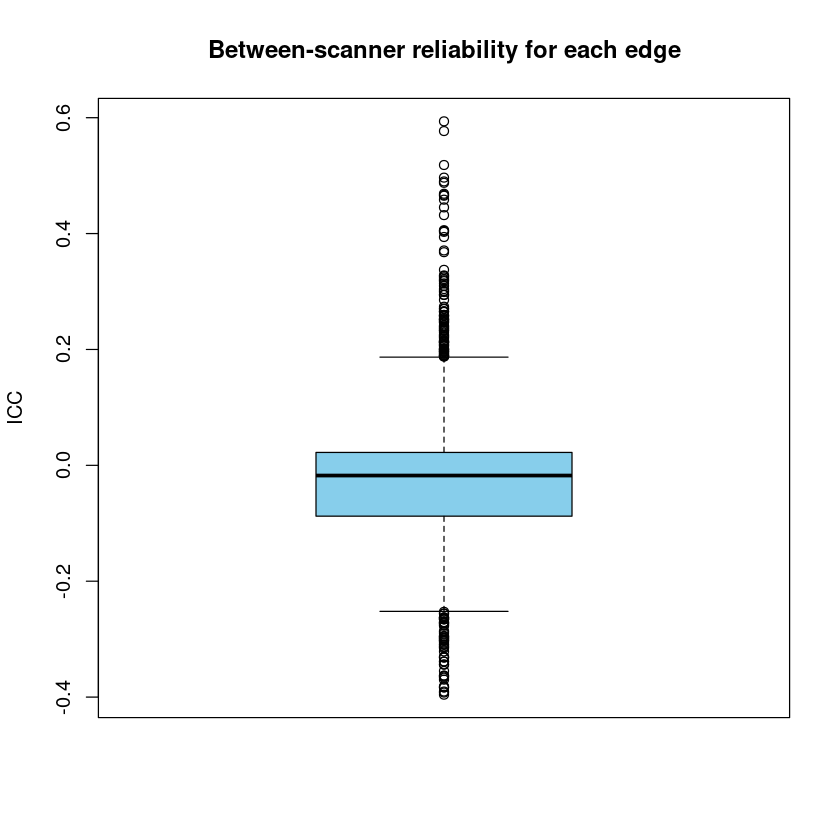

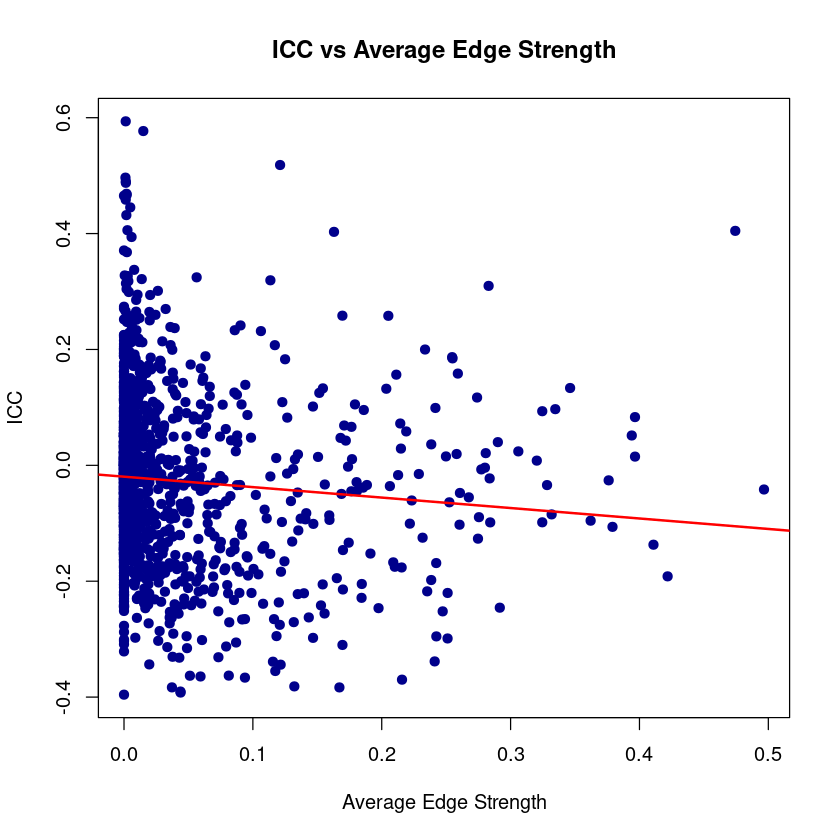

In [31]:
mean_icc <- mean(icc_vals$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_vals$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_vals$ICC, main = "Between-scanner reliability for each edge", ylab = "ICC", col = "skyblue")

# Calculate average edge strength across all sessions for each edge
avg_edge_strength <- sapply(edge_keys, function(edge) mean(df_fc[[edge]], na.rm = TRUE))

# Merge ICC values and average edge strength into a data frame
icc_vs_strength <- data.frame(
    edge = edge_keys,
    ICC = icc_vals$ICC,
    avg_strength = avg_edge_strength
)

# Plot ICC versus average edge strength
plot(
    icc_vs_strength$avg_strength, icc_vs_strength$ICC,
    xlab = "Average Edge Strength",
    ylab = "ICC",
    main = "ICC vs Average Edge Strength",
    pch = 19, col = "darkblue"
)
abline(lm(ICC ~ avg_strength, data = icc_vs_strength), col = "red", lwd = 2)

In [32]:
icc_between <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), slept = numeric(), fd_mean = numeric(), fd_diff = numeric(), stringsAsFactors = FALSE)

scanners <- unique(df_fc$scanner)
# Iterate over the three possible scanner pairs
for (i in 1:2) {
  for (j in (i + 1):3) {

    # Iterate over all possible pairs of repetition
    for (rep1 in 1:12) {
      for (rep2 in 1:12) {
        sc1 <- scanners[i]
        sc2 <- scanners[j]

        # Extract that permutation of repetitions
        df_rep <- rbind(subset(df_fc, scanner == sc1 & repetition == rep1), subset(df_fc, scanner == sc2 & repetition == rep2))

        # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
          if (any(is.na(df_rep$slept))) {
              # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
              slept <- NA
          } else {
              df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
              slept <- sum(df_rep$slept)
          }
        # Indicate mean and difference of FD between the two repetitions
        fd_mean <- mean(df_rep$fd_mean)
        fd_diff <- abs(diff(df_rep$fd_mean))

        # Keep only the edge column and trasnpose the dataframe
        col_names <- df_rep$scanner
        df_edges <- t(df_rep[, edge_keys])  # rows: edges, cols: scanners
        colnames(df_edges) <- col_names

        # Compute ICC(2,1)
        icc_val <- icc(df_edges, model = "twoway", type = "agreement", unit = "single")$value

        # Store the results
        icc_between <- rbind(
            icc_between,
            data.frame(
            variability_type = "between-scanner",
            task = "rest",
            scanner = paste0(scanners[i], "-", scanners[j]),
            repetition = paste0(rep1, "-", rep2),
            ICC = icc_val,
            summary_statistic = NA,
            days_diff = NA,
            slept = slept,
            fd_mean = fd_mean,
            fd_diff = fd_diff
            )
        )  
      }
    }
  }
}

head(df_rep)
head(icc_between)

,subject,session,scanner,repetition,acq_time,pe_dir,fd_mean,slept_rest,edge1,edge2,⋯,edge1883,edge1884,edge1885,edge1886,edge1887,edge1888,edge1889,edge1890,edge1891,slept
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
34,001,21201030,vidafit,12,2024-09-04T22:03:14.402500,RL,0.09497931,Yes,-1.052766e-06,-1.828220e-06,⋯,-1.829030e-18,-6.324279e-18,5.503131e-17,0.04869998,-3.171171e-17,2.214591e-17,2.255239e-17,5.606462e-17,-1.793980e-17,1
35,001,21202034,vida,12,2024-09-04T23:53:45.627500,LR,0.11164628,No,-1.245544e-05,8.131475e-06,⋯,-6.635317e-17,-5.546768e-17,-1.068744e-16,0.07288537,3.981117e-17,5.584283e-17,9.981604e-18,-1.399680e-17,2.566444e-02,0


,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept,fd_mean,fd_diff
,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>
1,between-scanner,rest,prisma-vidafit,1-1,0.7248010,NA,NA,1,0.10096223,0.0045027268
2,between-scanner,rest,prisma-vidafit,1-2,0.6914540,NA,NA,1,0.09312841,0.0201703669
3,between-scanner,rest,prisma-vidafit,1-3,0.6857878,NA,NA,1,0.10327724,0.0001272954
4,between-scanner,rest,prisma-vidafit,1-4,0.8622219,NA,NA,2,0.11979830,0.0331694264
5,between-scanner,rest,prisma-vidafit,1-5,0.8590276,NA,NA,2,0.11075496,0.0150827461
6,between-scanner,rest,prisma-vidafit,1-6,0.6843263,NA,NA,1,0.10734953,0.0082718831


In [33]:
mean_icc <- mean(icc_between$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_between$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_between <- rbind(
    icc_between,
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA)
)

Mean ICC across edges: 0.7962891 
Quantiles (25%, median, 75%): 0.7290755 0.8052386 0.858852 


## ICC to quantify intra-scanner variability when using standard resting-state

Let's quantify the intra-scanner reliability of FC estimates when using the standard fixation cross task for resting-state.

### Using all 12 sessions

In [34]:
icc_within_rest <- list()
for (scanner in unique(df_fc$scanner)) {
    df_scanner <- df_fc[df_fc$scanner == scanner, ]
    df_scanner <- t(df_scanner[, edge_keys])
    icc_within_rest[[scanner]] <- icc(df_scanner, model = "twoway", type = "agreement", unit = "single")$value
    cat(sprintf("ICC of for %s scanner: %.4f\n", scanner, icc_within_rest[[scanner]]))
}
head(df_scanner)

ICC of for prisma scanner: 0.7800
ICC of for vidafit scanner: 0.7962
ICC of for vida scanner: 0.8155


,3,6,8,11,14,16,19,23,27,30,31,35
edge1,6.528042e-06,-4.514564e-06,-8.506657e-06,-3.215814e-06,-5.611867e-06,-1.163362e-06,-1.055886e-06,9.467434e-07,3.087218e-06,1.113368e-06,-4.712413e-06,-1.245544e-05
edge2,7.514955e-06,2.766009e-02,-4.268188e-06,-1.695434e-06,-9.683560e-07,3.029625e-06,-9.775773e-06,-1.016135e-06,7.646137e-07,-4.235880e-06,-6.342809e-06,8.131475e-06
edge3,6.689939e-02,1.460895e-05,9.157005e-02,9.144441e-02,3.725246e-03,1.416232e-01,9.480423e-08,4.164482e-02,1.045742e-02,-4.391880e-06,8.693893e-02,-2.167989e-05
edge4,7.235371e-06,4.672855e-04,1.805981e-02,6.709116e-02,6.825498e-02,5.305358e-02,4.791103e-02,1.185077e-02,-2.287152e-05,2.343900e-05,9.511922e-03,1.151996e-05
edge5,-7.886987e-07,-4.646385e-06,-4.847092e-06,-7.981107e-07,1.155399e-07,-1.123034e-06,7.750204e-07,-9.281694e-09,1.307680e-06,-1.880596e-06,6.730842e-08,-7.215465e-06
edge6,7.797121e-06,-2.661734e-07,-1.059137e-06,-1.370371e-06,-2.018452e-06,1.328749e-07,-2.814641e-07,-2.565683e-07,-3.477949e-07,-1.781178e-06,-2.678140e-09,5.341054e-06


### Bootstrap all possible pairs of repetitions

In [35]:
icc_intra_rest <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), slept = numeric(), fd_mean = numeric(), fd_diff = numeric(), stringsAsFactors = FALSE)

for (scanner in unique(df_fc$scanner)) {
    df_scanner <- df_fc[df_fc$scanner == scanner, ]
    # Iterate over all possible pairs of repetition
    for (rep1 in 1:11) {
      # Ensure rep2 is always greater than rep1 to avoid duplicates
      for (rep2 in (rep1+1):12) {

            # Extract that permutation of repetitions
            df_rep <- rbind(subset(df_scanner, repetition == rep1), subset(df_scanner, repetition == rep2))
            # Compute how many days apart the two repetitions are
            days_diff <- as.numeric(abs(as.Date(df_rep$acq_time[1]) - as.Date(df_rep$acq_time[2])))
            # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
            if (any(is.na(df_rep$slept))) {
                # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
                slept <- NA
            } else {
                df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
                slept <- sum(df_rep$slept)
            }
            # Indicate mean and difference of FD between the two repetitions
            fd_mean <- mean(df_rep$fd_mean)
            fd_diff <- abs(diff(df_rep$fd_mean))

            #Keep only the edge column and transpose the dataframe
            df_rep <- t(df_rep[, edge_keys])

            # Compute ICC(2,1)
            icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
            icc_intra_rest <- rbind(icc_intra_rest, data.frame(variability_type = "within-scanner", task="rest", scanner=scanner, repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff, slept=slept, fd_mean = fd_mean, fd_diff = fd_diff))
        }
    }
}
head(df_rep)
head(icc_intra_rest)

,31,35
edge1,-4.712413e-06,-1.245544e-05
edge2,-6.342809e-06,8.131475e-06
edge3,8.693893e-02,-2.167989e-05
edge4,9.511922e-03,1.151996e-05
edge5,6.730842e-08,-7.215465e-06
edge6,-2.678140e-09,5.341054e-06


,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept,fd_mean,fd_diff
,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
1,within-scanner,rest,prisma,1-2,0.8411719,NA,1,2,0.1103396,0.014251945
2,within-scanner,rest,prisma,1-3,0.8031777,NA,2,2,0.1226884,0.038949594
3,within-scanner,rest,prisma,1-4,0.6667641,NA,3,1,0.1094771,0.012526925
4,within-scanner,rest,prisma,1-5,0.6836485,NA,4,1,0.1169187,0.027410283
5,within-scanner,rest,prisma,1-6,0.8539780,NA,5,2,0.1011639,0.004099296
6,within-scanner,rest,prisma,1-7,0.7105431,NA,7,1,0.1148795,0.023331863


In [36]:
for (scanner in unique(df_fc$scanner)) {
    icc_intra_rest_scanner <- icc_intra_rest[icc_intra_rest$scanner == scanner, ]
    mean_icc <- mean(icc_intra_rest_scanner$ICC, na.rm = TRUE)
    cat("Scanner:", scanner, "\n")
    cat("Mean ICC across edges:", mean_icc, "\n")
    quantiles <- quantile(icc_intra_rest_scanner$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
    cat("Quantiles (25%, median, 75%):", quantiles, "\n")

    icc_intra_rest <- rbind(
        icc_intra_rest,
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = slept, fd_mean = NA, fd_diff = NA),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = slept, fd_mean = NA, fd_diff = NA),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = slept, fd_mean = NA, fd_diff = NA),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = slept, fd_mean = NA, fd_diff = NA)
    )
}

Scanner: prisma 
Mean ICC across edges: 0.7798401 
Quantiles (25%, median, 75%): 0.7138741 0.7544129 0.8457678 
Scanner: vidafit 
Mean ICC across edges: 0.7952864 
Quantiles (25%, median, 75%): 0.7186016 0.8030623 0.8593237 
Scanner: vida 
Mean ICC across edges: 0.8160605 
Quantiles (25%, median, 75%): 0.7821268 0.8340833 0.8628899 


## ICC to quantify intra-scanner variability when using naturalistic movie

### Using all 36 sessions

In [37]:
df_intra_rsmovie <- t(df_rsmovie[, edge_keys])
head(df_intra_rsmovie)
icc_val_intra_rsmovie <- icc(df_intra_rsmovie, model = "twoway", type = "agreement", unit = "single")$value
cat(sprintf("ICC for rsmovie: %.4f\n", icc_val_intra_rsmovie))

edge1,1.102220e-06,6.415947e-06,-4.595372e-06,3.259803e-06,1.441370e-05,7.021473e-06,-1.020239e-06,5.842345e-05,-7.386642e-07,-1.819866e-06,⋯,1.427782e-07,1.067174e-06,-4.284423e-06,-1.063658e-05,-6.137563e-06,-4.678330e-06,-4.588838e-07,-5.199323e-06,-1.930210e-06,1.125792e-06
edge2,-7.794015e-07,-6.468752e-07,-2.194737e-06,-6.716801e-07,6.054336e-06,2.366883e-06,1.464118e-07,1.635985e-04,3.472887e-06,-1.046269e-07,⋯,-2.036710e-07,9.921960e-08,-3.770929e-06,3.638309e-02,-7.807891e-06,1.433800e-02,-4.062786e-07,1.576103e-02,5.235316e-02,6.780837e-06
edge3,1.139434e-05,5.280384e-06,-8.793063e-06,5.543463e-03,1.137742e-05,5.896386e-02,-1.159955e-06,4.520909e-05,-1.051122e-06,-7.542363e-06,⋯,-2.609990e-06,-2.594676e-06,-5.589937e-06,2.233237e-02,1.421963e-01,-1.567289e-05,-2.738721e-06,9.256322e-06,-1.077018e-05,5.888299e-07
edge4,-2.108473e-05,3.844471e-02,6.452152e-02,3.652434e-02,5.151805e-02,2.030996e-05,4.823714e-02,8.268471e-02,4.989634e-02,5.762318e-02,⋯,4.310278e-02,4.568402e-02,2.367034e-05,-3.039112e-05,-2.870628e-05,7.280732e-06,-5.724659e-06,-2.320633e-06,-1.551173e-06,9.287778e-06
edge5,-5.255465e-07,1.069534e-06,-1.941939e-06,1.990934e-07,6.011015e-06,-1.473689e-07,-4.917529e-07,1.050275e-04,2.452045e-07,-9.815775e-07,⋯,-1.558604e-07,3.366410e-07,-3.251314e-06,3.433093e-06,1.607545e-07,-1.188681e-06,1.352869e-07,1.584268e-08,1.891379e-07,-1.540721e-06
edge6,-6.066261e-06,4.212206e-07,-4.056693e-06,-7.268224e-07,5.638678e-06,1.130457e-06,-5.580014e-08,2.000679e-04,-1.388992e-07,-1.986019e-08,⋯,-2.985605e-07,8.313284e-08,-2.428235e-06,2.739582e-06,-3.661786e-06,6.245403e-06,-4.533894e-08,-4.280846e-07,5.141747e-07,5.194488e-06


ICC for rsmovie: 0.8726


### Bootstrap to permute through all possible pairs of repetitions

In [38]:
icc_intra_rsmovie <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(),slept = numeric(),fd_mean=numeric(), fd_diff = numeric(), stringsAsFactors = FALSE)

# Iterate over all possible pairs of repetition
for (rep1 in 1:35) {
  # Ensure rep2 is always greater than rep1 to avoid duplicates
  for (rep2 in (rep1+1):36) {

        # Extract that permutation of repetitions
        df_rep <- rbind(subset(df_rsmovie, repetition == rep1), subset(df_rsmovie, repetition == rep2))
        # Compute how many days apart the two repetitions are
        days_diff <- as.numeric(abs(as.Date(df_rep$acq_time[1]) - as.Date(df_rep$acq_time[2])))
        # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
            if (any(is.na(df_rep$slept))) {
                # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
                slept <- NA
            } else {
                df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
                slept <- sum(df_rep$slept)
            }
        # Indicate mean and difference of FD between the two repetitions
        fd_mean <- mean(df_rep$fd_mean)
        fd_diff <- abs(diff(df_rep$fd_mean))
        
        #Keep only the edge column and transpose the dataframe
        df_rep <- t(df_rep[, edge_keys])

        # Compute ICC(2,1)
        icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
        icc_intra_rsmovie <- rbind(icc_intra_rsmovie, data.frame(variability_type = "within-scanner", task="rsmovie", scanner="prisma", repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff, slept=slept, fd_mean = fd_mean, fd_diff = fd_diff))
    }
}
head(df_rep)
head(icc_intra_rsmovie)

,35,36
edge1,-1.930210e-06,1.125792e-06
edge2,5.235316e-02,6.780837e-06
edge3,-1.077018e-05,5.888299e-07
edge4,-1.551173e-06,9.287778e-06
edge5,1.891379e-07,-1.540721e-06
edge6,5.141747e-07,5.194488e-06


,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept,fd_mean,fd_diff
,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
1,within-scanner,rsmovie,prisma,1-2,0.8672726,NA,1,NA,0.1076399,0.023209393
2,within-scanner,rsmovie,prisma,1-3,0.8910870,NA,1,NA,0.1330632,0.027637322
3,within-scanner,rsmovie,prisma,1-4,0.9170888,NA,2,NA,0.1157687,0.006951756
4,within-scanner,rsmovie,prisma,1-5,0.8804258,NA,2,NA,0.1039726,0.030543944
5,within-scanner,rsmovie,prisma,1-6,0.8710908,NA,3,NA,0.1101425,0.018204154
6,within-scanner,rsmovie,prisma,1-7,0.8849407,NA,3,NA,0.1131080,0.012273137


In [39]:
mean_icc <- mean(icc_intra_rsmovie$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_intra_rsmovie$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_intra_rsmovie <- rbind(
    icc_intra_rsmovie,
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA)
)

Mean ICC across edges: 0.8723939 
Quantiles (25%, median, 75%): 0.8581244 0.8760093 0.8911141 


## ICC to quantify variability across paradigms

In [40]:
icc_vals <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Randomly select 12 sessions from the rsmovie task because we need to have the same number of sessions for each task to be able to compute ICC
selected_sessions <- sample(unique(df_fc_paradigm$repetition[df_fc_paradigm$task == "rsmovie"]), 12)
df_paradigm <- df_fc_paradigm[df_fc_paradigm$repetition %in% selected_sessions | df_fc_paradigm$task == "rest", ]

for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_paradigm[, c( "task", edge)]
    df_icc <- pivot_wider(df_icc, names_from = task, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(rest, rsmovie))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_vals <- rbind(icc_vals, data.frame(edge = edge, ICC = icc_val))
}
df_icc
head(icc_vals)

rest,rsmovie
<dbl>,<dbl>
5.167582e-17,8.938102e-17
-3.850324e-17,8.876246e-17
1.681766e-17,5.087166e-03
-1.098919e-16,2.153437e-16
1.035807e-02,-1.642213e-16
-7.349301e-17,2.059626e-16
-3.314509e-17,2.643575e-02
3.888169e-02,3.364277e-17
7.479356e-17,3.862706e-02


,edge,ICC
,<chr>,<dbl>
1,edge1,-0.0309094879
2,edge2,-0.1201255570
3,edge3,0.0005859658
4,edge4,-0.0653274767
5,edge5,-0.0325226747
6,edge6,0.0161130146


Mean ICC across edges: 0.002744327 
Median ICC across edges: -9.245724e-05 


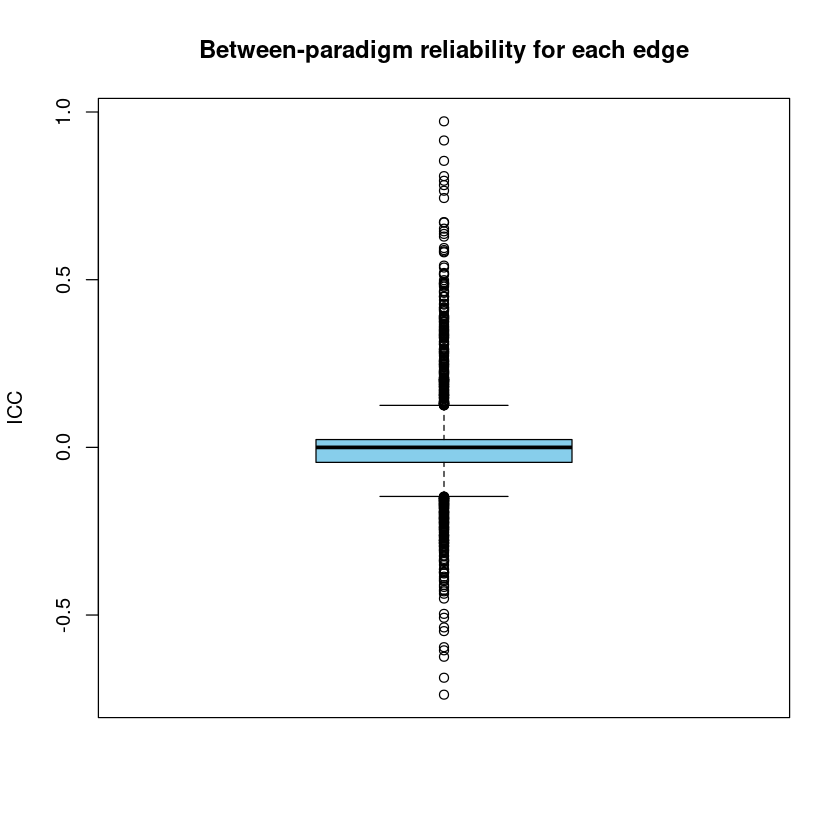

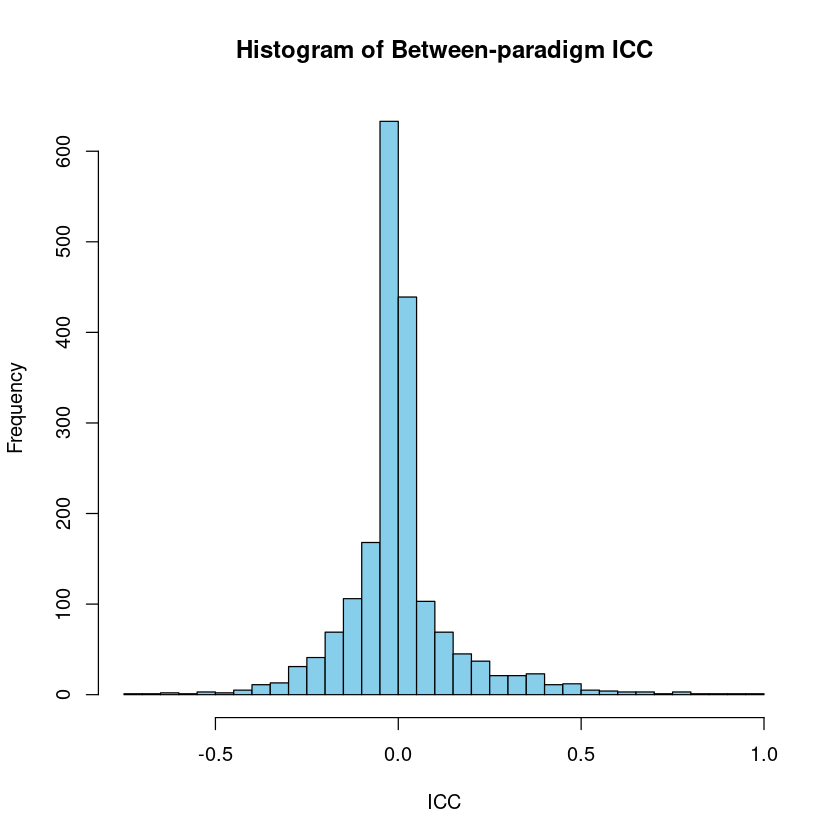

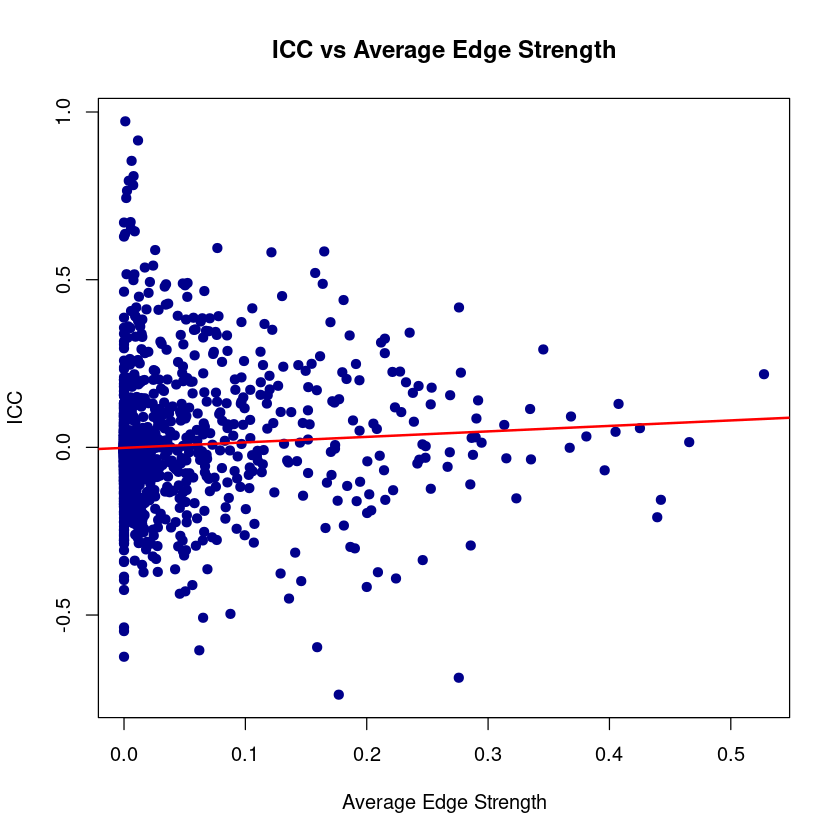

In [41]:
mean_icc <- mean(icc_vals$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_vals$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_vals$ICC, main = "Between-paradigm reliability for each edge", ylab = "ICC", col = "skyblue")
hist(icc_vals$ICC, breaks = 30, main = "Histogram of Between-paradigm ICC", xlab = "ICC", col = "skyblue")

# Calculate average edge strength across all sessions for each edge
avg_edge_strength <- sapply(edge_keys, function(edge) mean(df_paradigm[[edge]], na.rm = TRUE))

# Merge ICC values and average edge strength into a data frame
icc_vs_strength <- data.frame(
    edge = edge_keys,
    ICC = icc_vals$ICC,
    avg_strength = avg_edge_strength
)

# Plot ICC versus average edge strength
plot(
    icc_vs_strength$avg_strength, icc_vs_strength$ICC,
    xlab = "Average Edge Strength",
    ylab = "ICC",
    main = "ICC vs Average Edge Strength",
    pch = 19, col = "darkblue"
)
abline(lm(ICC ~ avg_strength, data = icc_vs_strength), col = "red", lwd = 2)

In [42]:
icc_paradigm <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), slept= numeric(),fd_mean=numeric(), fd_diff=numeric(), stringsAsFactors = FALSE)

# Iterate over all possible combinations of repetition numbers for the 3 scanners
tasks <- unique(df_fc_paradigm$task)
for (rep1 in 1:12) {
  for (rep2 in 1:36) {

        # Extract that permutation of repetitions
        reps <- c(rep1, rep2)
        df_rep <- data.frame()
        for (i in 1:2) {
          df_one <- subset(df_fc_paradigm, task == tasks[i] & repetition == reps[i])
          df_rep <- rbind(df_rep, df_one)
        }
        # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
        if (any(is.na(df_rep$slept))) {
            # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
            slept <- NA
        } else {
            df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
            slept <- sum(df_rep$slept)
        }
        # Indicate mean and difference of FD between the two repetitions
        fd_mean <- mean(df_rep$fd_mean)
        fd_diff <- abs(diff(df_rep$fd_mean))
        
        # Keep only the edge column and transpose the dataframe
        colnames <- df_rep$task
        df_rep <- t(df_rep[, edge_keys])
        colnames(df_rep) <- colnames
        # Compute ICC(2,1) for this edge
        icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
        icc_paradigm <- rbind(icc_paradigm, data.frame(variability_type = "between-paradigm", task=NA, scanner="prisma", repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff, slept = slept, fd_mean = fd_mean, fd_diff = fd_diff))
    }
}
head(df_rep)
head(icc_paradigm)

,rest,rsmovie
edge1,-1.738165e-06,1.125792e-06
edge2,-1.091652e-06,6.780837e-06
edge3,1.356319e-05,5.888299e-07
edge4,6.414071e-02,9.287778e-06
edge5,4.221924e-07,-1.540721e-06
edge6,3.592163e-07,5.194488e-06


,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept,fd_mean,fd_diff
,<chr>,<lgl>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
1,between-paradigm,NA,prisma,1-1,0.6526815,NA,0,NA,0.11122908,0.016030980
2,between-paradigm,NA,prisma,1-2,0.7528309,NA,0,NA,0.09962438,0.007178413
3,between-paradigm,NA,prisma,1-3,0.6810927,NA,0,1,0.12504774,0.043668302
4,between-paradigm,NA,prisma,1-4,0.6820359,NA,0,1,0.10775320,0.009079225
5,between-paradigm,NA,prisma,1-5,0.6857914,NA,0,1,0.09595711,0.014512964
6,between-paradigm,NA,prisma,1-6,0.7252604,NA,0,1,0.10212700,0.002173174


In [43]:
mean_icc <- mean(icc_paradigm$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_paradigm$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_paradigm <- rbind(
    icc_paradigm,
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA)
)

Mean ICC across edges: 0.7718473 
Quantiles (25%, median, 75%): 0.7202751 0.7796572 0.8268158 


## Save the ICC estimates in a table

We use pybids to determine the filename to save the table.

In [5]:
py_run_string(" 
save_path = Path('/data/derivatives/hcph-suppl/')
save_layout = BIDSLayout(save_path, config='hcph', indexer=_indexer, validate=False)
entities = {
    'experiment': 'scannereffects',
    'extension': '.tsv',
    'datatype': 'tables',
    'suffix': 'bold',
    'desc': 'icc'
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")

In [6]:
icc_results <- rbind(icc_between, icc_paradigm, icc_intra_rsmovie, icc_intra_rest)

write.table(icc_results, file = py$save_path, sep = "\t", row.names = FALSE, col.names = TRUE, quote = FALSE)

ERROR: Error in eval(expr, envir, enclos): object 'icc_between' not found


## Visualize the ICC results

Load all the ICC computed for both connectivity measure: correlation and sparse inverse covariance.

In [6]:
py_run_string(" 
save_path = Path('/data/derivatives/hcph-suppl/')
save_layout = BIDSLayout(save_path, config='hcph', indexer=_indexer, validate=False)
entities = {
    'experiment': 'scannereffects',
    'extension': '.tsv',
    'datatype': 'tables',
    'suffix': 'bold',
    'desc': 'icc'
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")

# Extract the measurement type from the filename
meas <- sub(".*meas-([a-zA-Z]+).*", "\\1", py$save_path)

# Determine the alternate measurement type
alt_meas <- ifelse(meas == "sparseinversecovariance", "correlation", "sparseinversecovariance")

# Construct the alternate file path
alt_save_path <- gsub(meas, alt_meas, py$save_path)

if (file.exists(py$save_path) && file.exists(alt_save_path)) {
    # Read the saved ICC results for both measurement types
    icc_results_1 <- read.table(py$save_path, sep = "\t", header = TRUE, stringsAsFactors = FALSE)
    icc_results_1$meas <- meas
    icc_results_2 <- read.table(alt_save_path, sep = "\t", header = TRUE, stringsAsFactors = FALSE)
    icc_results_2$meas <- alt_meas

    # Combine the results into a single data frame
    icc_combined <- rbind(icc_results_1, icc_results_2)
    head(icc_combined)
} else {
    cat("The following files must exist at the specified paths:\n")
    cat(py$save_path, "\n")
    cat(alt_save_path, "\n")
    cat("Please run the upper part of the notebook to compute the ICC first.")
}

,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept,fd_mean,fd_diff,meas
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>
1,between-scanner,rest,prisma-vidafit,1-1,0.7248010,NA,NA,1,0.10096223,0.0045027268,sparseinversecovariance
2,between-scanner,rest,prisma-vidafit,1-2,0.6914540,NA,NA,1,0.09312841,0.0201703669,sparseinversecovariance
3,between-scanner,rest,prisma-vidafit,1-3,0.6857878,NA,NA,1,0.10327724,0.0001272954,sparseinversecovariance
4,between-scanner,rest,prisma-vidafit,1-4,0.8622219,NA,NA,2,0.11979830,0.0331694264,sparseinversecovariance
5,between-scanner,rest,prisma-vidafit,1-5,0.8590276,NA,NA,2,0.11075496,0.0150827461,sparseinversecovariance
6,between-scanner,rest,prisma-vidafit,1-6,0.6843263,NA,NA,1,0.10734953,0.0082718831,sparseinversecovariance


Separate variability types into their standalone dataframes and prepare the dataframes for plotting.

In [ ]:
# Within-scanner with naturalistic movie
icc_intra_rsmovie <- icc_combined[icc_combined$variability_type == "within-scanner" & icc_combined$meas == meas & icc_combined$task == "rsmovie", ]
icc_intra_rsmovie$slept_factor <- factor(
    ifelse(is.na(icc_intra_rsmovie$slept), -1, icc_intra_rsmovie$slept),
    levels = c(0, 1, 2, -1),
    labels = c("Slept in no session", "Slept in one session", "Slept in both sessions", "Unknown")
)

# Within-scanner with standard resting-state
icc_intra_rest <- icc_combined[icc_combined$variability_type == "within-scanner" & icc_combined$meas == meas & icc_combined$task == "rest", ]
icc_intra_rest$slept_factor <- factor(
    ifelse(is.na(icc_intra_rest$slept), -1, icc_intra_rest$slept),
    levels = c(0, 1, 2, -1),
    labels = c("Slept in no session", "Slept in one session", "Slept in both sessions", "Unknown")
)

# Between-scanner
icc_between <- icc_combined[icc_combined$variability_type == "between-scanner" & icc_combined$meas == meas, ]
icc_between$slept_factor <- factor(
    ifelse(is.na(icc_between$slept), -1, icc_between$slept),
    levels = c(0, 1, 2, -1),
    labels = c("Slept in no session", "Slept in one session", "Slept in both sessions", "Unknown")
)
icc_between$scanner_factor <- factor(
    icc_between$scanner,
    levels = c("prisma-vida", "prisma-vidafit", "vidafit-vida"),
    labels = c("Prisma - Vida", "Prisma - VidaFit", "Vida - VidaFit")
)

# Between-paradigm
icc_paradigm <- icc_combined[icc_combined$variability_type == "between-paradigm" & icc_combined$meas == meas, ]
icc_paradigm$slept_factor <- factor(
    ifelse(is.na(icc_paradigm$slept), -1, icc_paradigm$slept),
    levels = c(0, 1, 2, -1),
    labels = c("Slept in no session", "Slept in one session", "Slept in both sessions", "Unknown")
)

# Filter only the bootstrap/permutation ICCs (exclude summary statistics)
df_plot <- icc_combined %>%
    filter(is.na(summary_statistic)) %>%
    mutate(
        variability_plotname = case_when(
            variability_type == "within-scanner" & task == "rsmovie" ~ "Within-scanner (rsmovie, prisma)",
            variability_type == "within-scanner" & task == "rest" & scanner == "prisma" ~ "Within-scanner (rest, prisma)",
            variability_type == "within-scanner" & task == "rest" & scanner == "vida" ~ "Within-scanner (rest, vida)",
            variability_type == "within-scanner" & task == "rest" & scanner == "vidafit" ~ "Within-scanner (rest, vidafit)",
            variability_type == "between-scanner" ~ "Between-scanner (rest)",
            variability_type == "between-paradigm" ~ "Between-paradigm (prisma)",
            TRUE ~ NA_character_
        )
    )

# Set factor order for plot
df_plot$meas <- factor(df_plot$meas, levels = c("sparseinversecovariance", "correlation"), labels = c("Sparse Inverse Covariance", "Correlation"))
df_plot$variability_plotname <- factor(df_plot$variability_plotname, levels = c(
    "Within-scanner (rsmovie, prisma)",
    "Within-scanner (rest, vida)",
    "Within-scanner (rest, vidafit)",
    "Within-scanner (rest, prisma)",    
    "Between-scanner (rest)",
    "Between-paradigm (prisma)"
))

#### Compare ICC across variability type and across connectivity measure

In [ ]:
# Perform Wilcoxon signed-rank test to compare ICC distribution with sparseinversecovariance versus correlation for each variability type
# ICC distribution are clearly not normal, so we use this non-parametric test instead of a t-test
icc_significance <- df_plot %>%
    group_by(variability_plotname) %>%
    summarise(
        p_value = wilcox.test(ICC ~ meas, data = cur_data())$p.value
    ) %>%
    mutate(
        significance = case_when(
            p_value < 0.001 ~ "***",
            p_value < 0.01 ~ "**",
            p_value < 0.05 ~ "*",
            TRUE ~ "ns"
        )
    )

print(icc_significance)

# Merge significance data with the plot data
df_plot <- df_plot %>%
    left_join(icc_significance, by = "variability_plotname")

# A tibble: 6 × 3
  variability_plotname               p_value significance
  <fct>                                <dbl> <chr>       
1 Within-scanner (rsmovie, prisma) 2.27e-116 ***         
2 Within-scanner (rest, vida)      3.85e- 10 ***         
3 Within-scanner (rest, vidafit)   1.49e-  7 ***         
4 Within-scanner (rest, prisma)    1.56e-  7 ***         
5 Between-scanner (rest)           1.25e- 42 ***         
6 Between-paradigm (prisma)        4.12e- 67 ***         


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


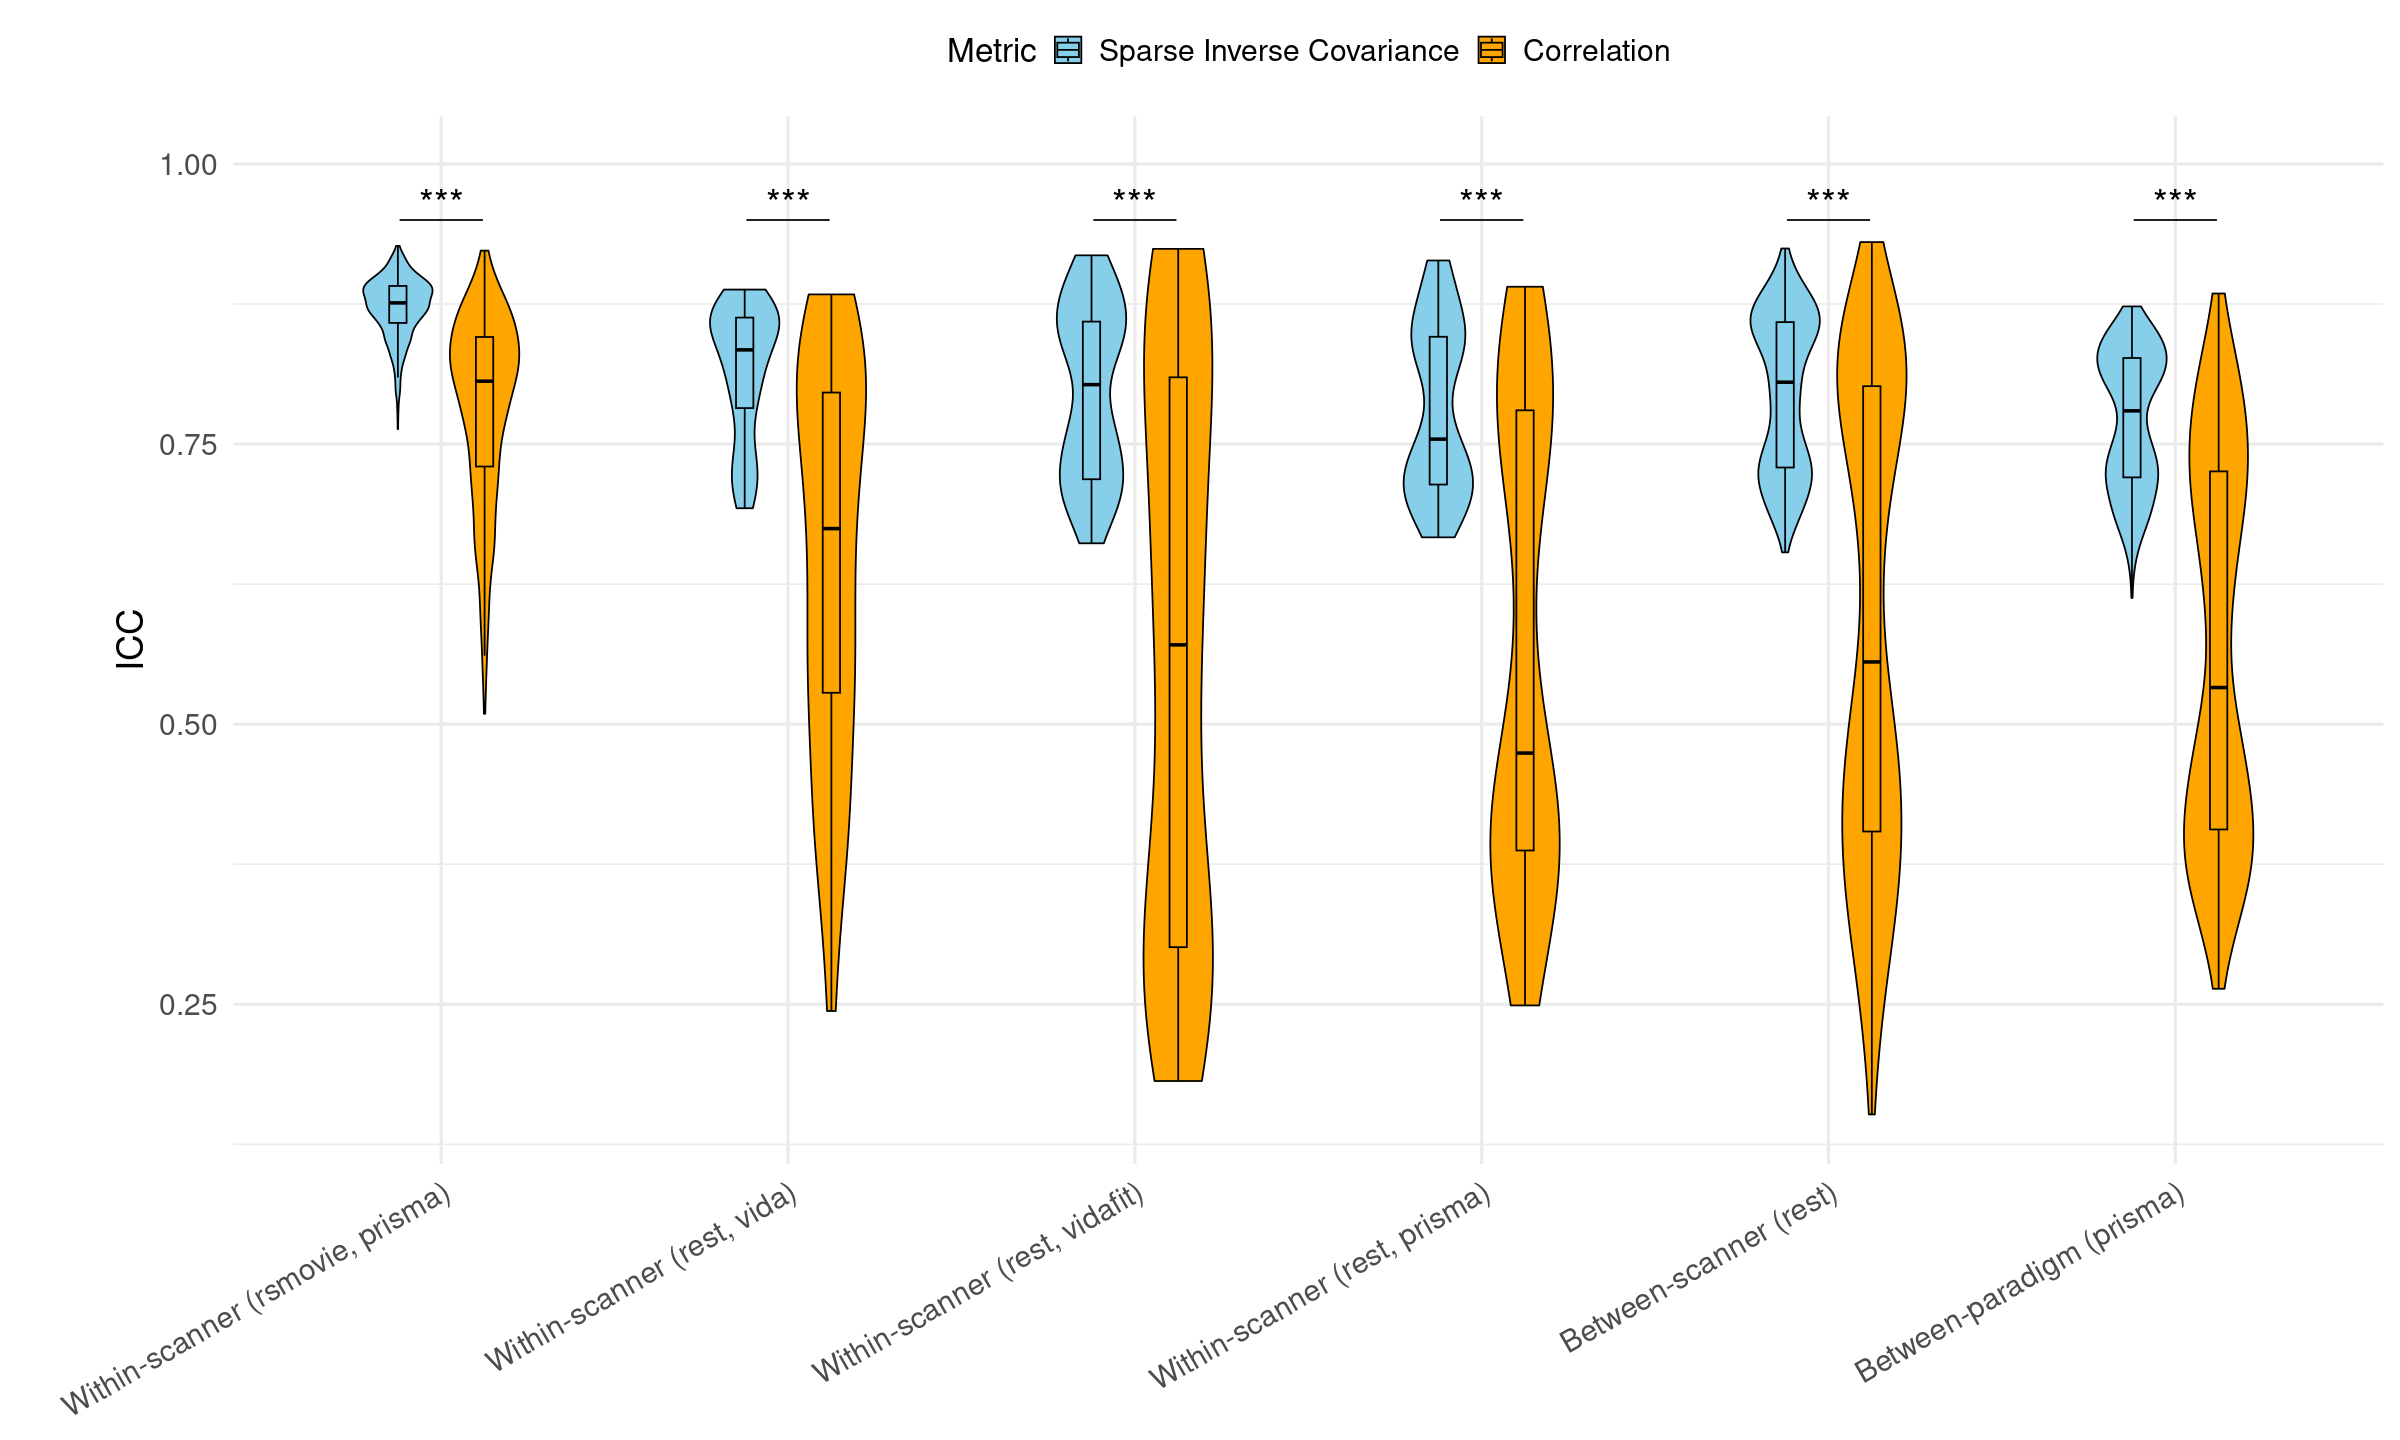

In [9]:
options(repr.plot.height = 12)
options(repr.plot.width = 20)

ggplot(df_plot, aes(x = variability_plotname, y = ICC, fill = meas)) +
    geom_violin(trim = TRUE, position = position_dodge(width = 0.5), color = "black", width = 0.4, scale="width") +
    geom_boxplot(aes(fill = meas), width = 0.1, position = position_dodge(width = 0.5), outlier.shape = NA, color = "black") +
    geom_segment(
        data = icc_significance,
        aes(
            x = as.numeric(variability_plotname) - 0.12,
            xend = as.numeric(variability_plotname) + 0.12 ,
            y = 0.95,
            yend = 0.95
        ),
        inherit.aes = FALSE,
        size = 0.5,
        color = "black"
    ) +
    geom_text(
        data = icc_significance,
        aes(
            x = as.numeric(variability_plotname),
            y = 0.94,
            label = significance
        ),
        inherit.aes = FALSE,
        size = 8,
        vjust = -0.5,
    ) +
    theme_minimal(base_size = 20) +
    labs(x = NULL, y = "ICC", fill = "Metric") +
    theme(
        axis.text.x = element_text(angle = 30, hjust = 1, size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.y = element_text(size = 22),
        plot.title = element_text(size = 24, face = "bold"),
        legend.position = "top",
        legend.text = element_text(size = 18),  # Increase legend text size
        legend.title = element_text(size = 20), # Increase legend title size
        plot.margin = margin(t = 10, r = 10, b = 10, l = 70)
    ) +
    scale_fill_manual(values = c("skyblue", "orange")) +
    ylim(0.15, 1.0)

# Save the plot to a file
py_run_string(" 
entities = {
    'experiment': 'scannereffects',
    'extension': '.png',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'icccomparative',
}
entities.update(entities_base)
entities['measure'] = None
save_path = save_layout.build_path(entities, validate=False)
#")
ggsave(filename = py$save_path, width = 12, height = 8, dpi = 300)


### Sleep influence on reliability

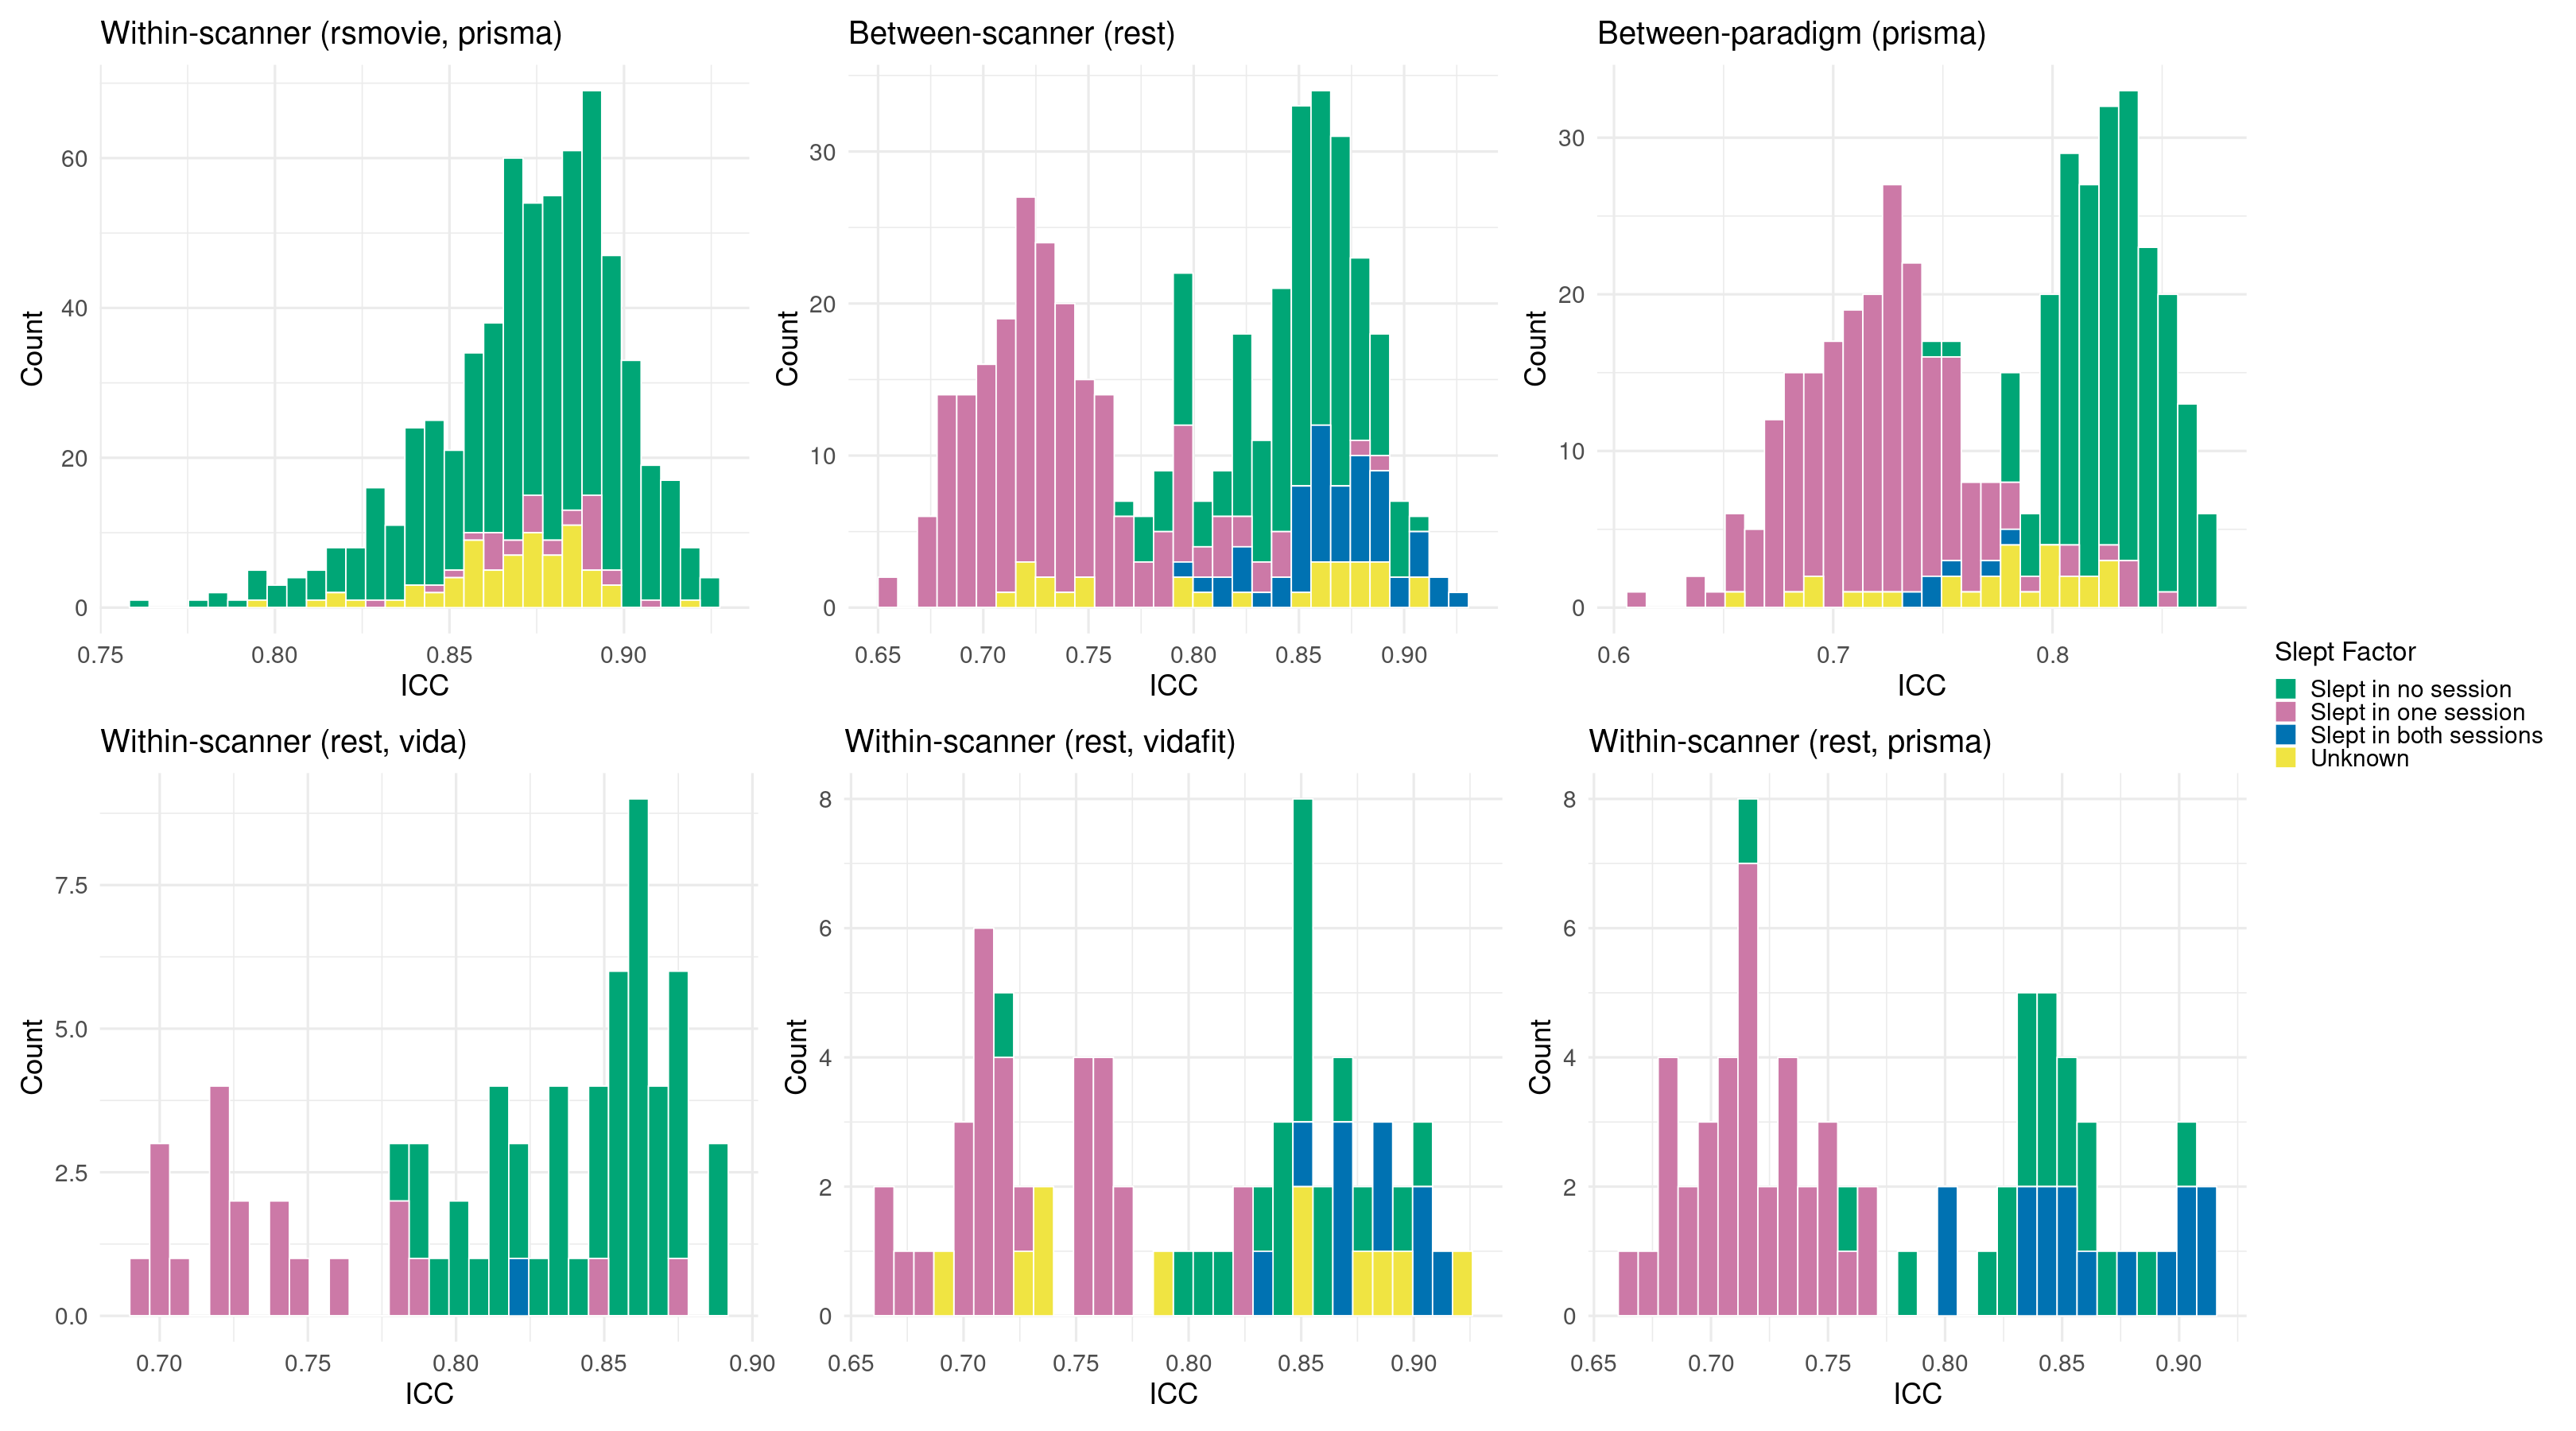

In [10]:
options(repr.plot.width = 27, repr.plot.height = 15)
# Plot
plot_rsmovie <- ggplot(data = icc_intra_rsmovie, aes(x = ICC, fill = slept_factor)) +
    geom_histogram(color = 'white', bins = 30, position = "stack") +
    labs(
        x = "ICC",
        y = "Count",
        fill = "Slept Factor",
        title = "Within-scanner (rsmovie, prisma)"
    ) +
    theme_minimal(base_size = 20) +
    theme(
        axis.text.x = element_text(size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        legend.text = element_text(size = 18),
        legend.title = element_text(size = 20),
        legend.position = "none" 
    ) +
    scale_fill_manual(values = c("#00A676", "#CC79A7", "#F0E442"))

plot_between <- ggplot(data = icc_between, aes(x = ICC, fill = slept_factor)) +
    geom_histogram(color = 'white', bins = 30, position = "stack") +
    labs(
        x = "ICC",
        y = "Count",
        fill = "Slept Factor",
        title = "Between-scanner (rest)"
    ) +
    theme_minimal(base_size = 20) +
    theme(
        axis.text.x = element_text(size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        legend.text = element_text(size = 18),
        legend.title = element_text(size = 20),
        legend.position = "none" 
    ) +
    scale_fill_manual(values = c("#00A676", "#CC79A7", "#0072B2", "#F0E442"))

plot_paradigm <- ggplot(data = icc_paradigm, aes(x = ICC, fill = slept_factor)) +
    geom_histogram(color = 'white', bins = 30, position = "stack") +
    labs(
        x = "ICC",
        y = "Count",
        fill = "Slept Factor",
        title = "Between-paradigm (prisma)"
    ) +
    theme_minimal(base_size = 20) +
    theme(
        axis.text.x = element_text(size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        legend.text = element_text(size = 18),
        legend.title = element_text(size = 20),
        legend.position = "right" 
    ) +
    scale_fill_manual(values = c("#00A676", "#CC79A7", "#0072B2", "#F0E442"))

# Create plots for each scanner
plots_scanners <- lapply(c("vida", "vidafit", "prisma"), function(scanner) {
    icc_intra_rest_scanner <- icc_intra_rest[icc_intra_rest$scanner == scanner, ]
    title <- switch(
        scanner,
        "vida" = "Within-scanner (rest, vida)",
        "vidafit" = "Within-scanner (rest, vidafit)",
        "prisma" = "Within-scanner (rest, prisma)"
    )
    ggplot(data = icc_intra_rest_scanner, aes(x = ICC, fill = slept_factor)) +
        geom_histogram(color = 'white', bins = 30, position = "stack") +
        labs(
            x = "ICC",
            y = "Count",
            fill = "Slept Factor",
            title = title
        ) +
        theme_minimal(base_size = 20) +
        theme(
            axis.text.x = element_text(size = 18),
            axis.text.y = element_text(size = 18),
            axis.title.x = element_text(size = 22),
            axis.title.y = element_text(size = 22),
            legend.text = element_text(size = 18),
            legend.title = element_text(size = 20),
            legend.position = "none"  # Hide legend for individual scanner plots
        ) +
        scale_fill_manual(values = c("#00A676", "#CC79A7", "#0072B2", "#F0E442"))
})

# Combine all plots into a single figure with one legend
combined_plot <- (plot_rsmovie | plot_between | plot_paradigm) / wrap_plots(plots_scanners, ncol = 3) +
    plot_layout(guides = "collect") 

# Save the plot to a file
py_run_string(" 
entities = {
    'experiment': 'scannereffects',
    'extension': '.png',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'iccVSsleep',
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")
ggsave(filename = py$save_path, width = 12, height = 8, dpi = 300)

# Display the combined plot
print(combined_plot)

As we see in the figure above, the bimodal distribution of ICC values reflects two distinct regimes: ICC is higher when the participant either consistently stayed awake or consistently fell asleep across both sessions, compared to when the participant was awake in one session and asleep in the other.

#### Did our participant exhibit a consistent pattern of sleeping more in a specific scanner? 

In [11]:
# Count occurrences of "Yes" and "No" for slept_rest for each scanner
print("Number of times the participant slept during the standard resting state session for each scanner:")
slept_counts <- df_fc %>%
    group_by(scanner) %>%
    summarise(
        slept_yes = sum(slept_rest == "Yes", na.rm = TRUE),
        slept_no = sum(slept_rest == "No", na.rm = TRUE)
    )

print(slept_counts)
cat("\n")

# Count occurrences of "Yes" and "No" for slept_rest in df_rsmovie
print("Number of times the participant slept during the naturalistic movie:")
slept_counts_rsmovie <- df_rsmovie %>%
    summarise(
        slept_yes = sum(slept_rest == "Yes", na.rm = TRUE),
        slept_no = sum(slept_rest == "No", na.rm = TRUE)
    )

print(slept_counts_rsmovie)

[1] "Number of times the participant slept during the standard resting state session for each scanner:"
# A tibble: 3 × 3
  scanner slept_yes slept_no
  <chr>       <int>    <int>
1 prisma          6        6
2 vida            2       10
3 vidafit         5        6

[1] "Number of times the participant slept during the naturalistic movie:"
  slept_yes slept_no
1         1       33


Two remarks about the numbers above:
1. Clearly the participant fell much less often asleep when the movie was playing. This is consistent with previous literature saying that playing a naturalistic movie helps remain awake. Interestingly, we showed in the figure above that sleeping leads to less reliable estimation of FC, hence using naturalistic movie can help obtaining more reliable estimate by preventing the participant to fall asleep.
2. The participant fell asleep less in the vida than the prisma and vidafit. Paired with the observation that sleeping reduces FC reliability, this could explain why vida shows remarkably higher ICC than prisma and vidafit.

#### Is there a scanner that is systematically less reliable than the other two?

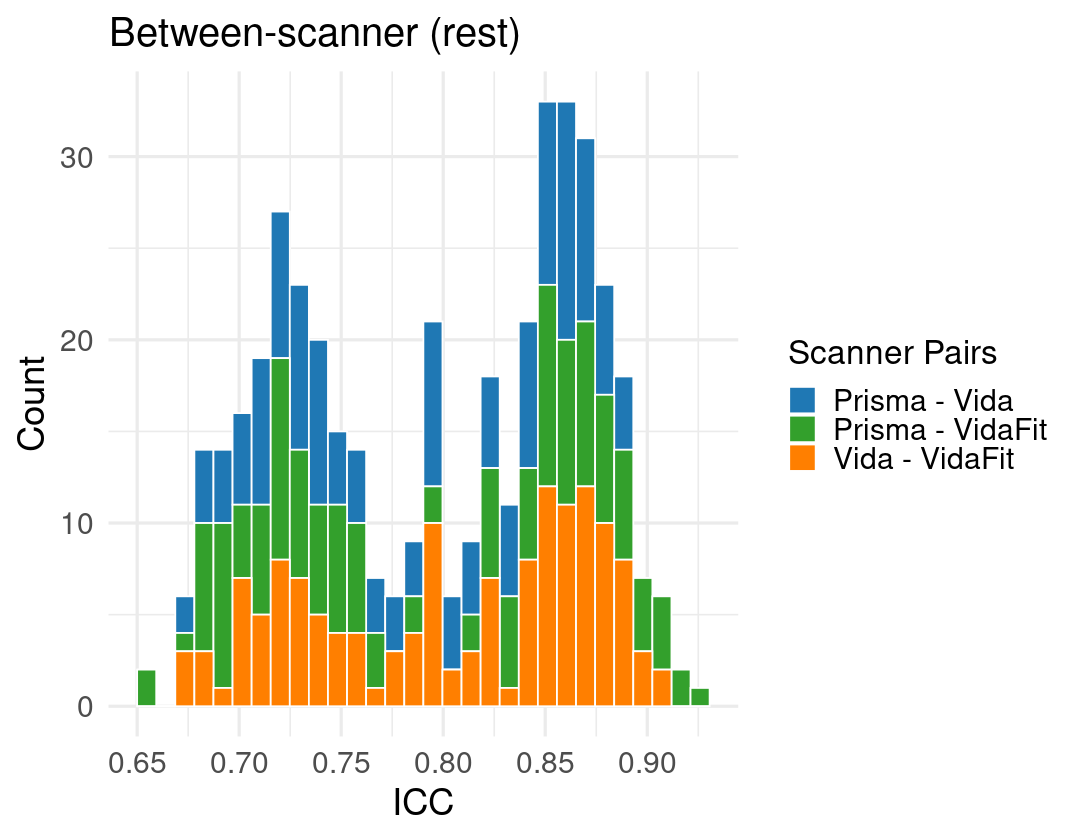

In [12]:
#Plot the ICC distribution by scanner pairs
options(repr.plot.width = 9, repr.plot.height = 7)
ggplot(data = icc_between[is.na(icc_between$summary_statistic), ], aes(x = ICC, fill = scanner_factor)) +
    geom_histogram(color = 'white', bins = 30, position = "stack") +
    labs(
        x = "ICC",
        y = "Count",
        fill = "Scanner Pairs",
        title = "Between-scanner (rest)"
    ) +
    theme_minimal(base_size = 20) +
    theme(
        axis.text.x = element_text(size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        legend.text = element_text(size = 18),
        legend.title = element_text(size = 20)
    ) +
    scale_fill_manual(values = c("#1F78B4", "#33A02C", "#FF7F00"))

# Save the plot to a file
py_run_string(" 
entities = {
    'experiment': 'scannereffects',
    'extension': '.png',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'iccVSscanner',
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")
ggsave(filename = py$save_path, width = 12, height = 8, dpi = 300)

The three pairs of scanner exhibit a similar ICC distribution indicating that no scanner is an outlier in terms of reliability

#### Did our participant consistently moved more in one scanner compared to the others? 

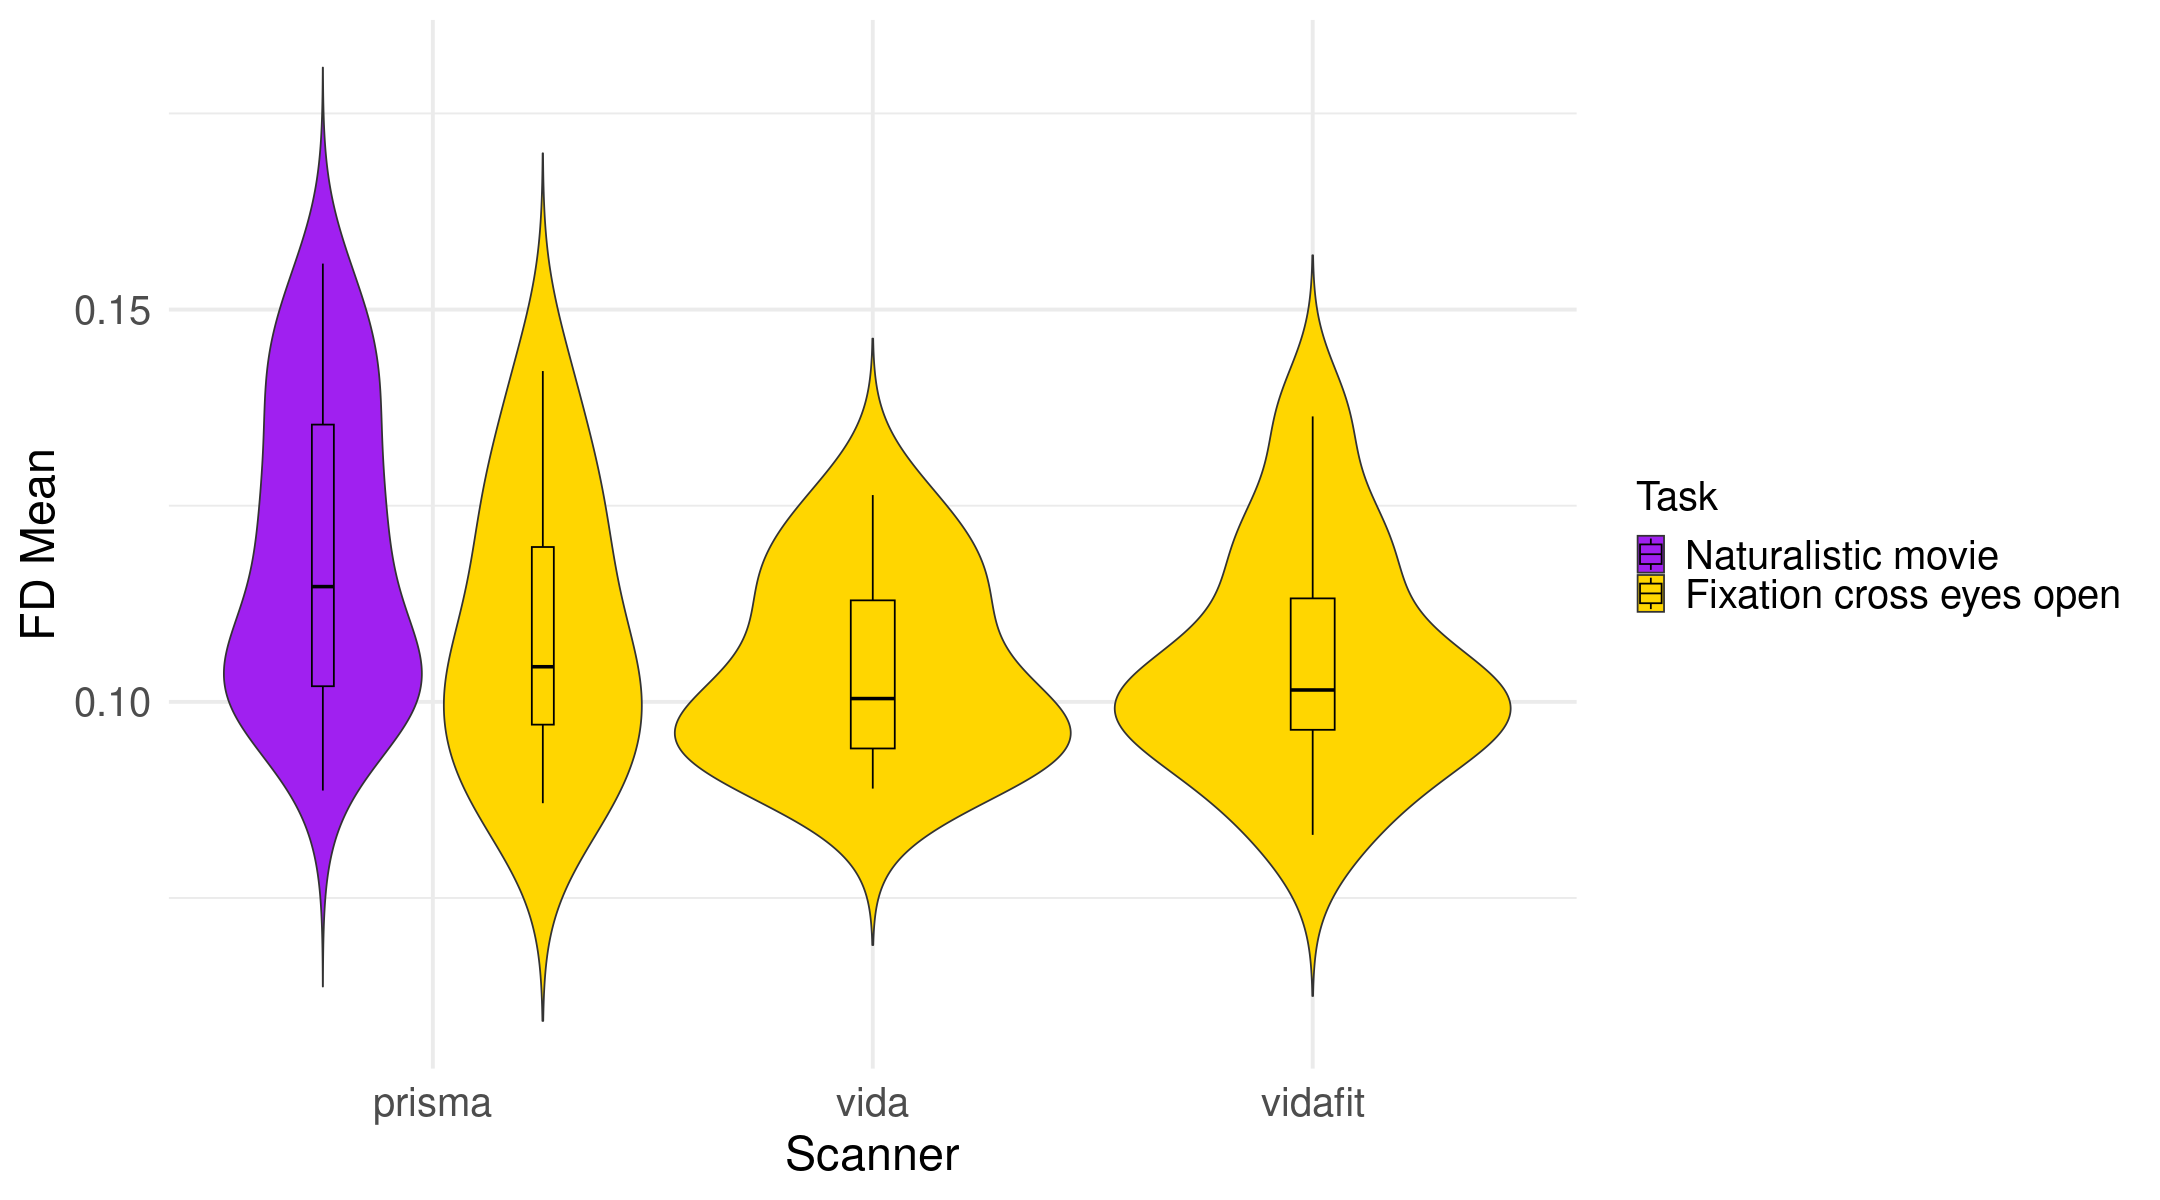

In [13]:
# Prepare data for plotting
df_fc_plot <- df_fc %>%
    select(scanner, fd_mean) %>%
    mutate(task = "rest")


df_rsmovie_plot <- df_rsmovie %>%
    select(fd_mean) %>%
    mutate(task = "rsmovie")
df_rsmovie_plot["scanner"] <- "prisma" 

df_fd_plot <- bind_rows(df_fc_plot, df_rsmovie_plot)

df_fd_plot$scanner <- factor(df_fd_plot$scanner, levels = c("prisma", "vida", "vidafit"))
df_fd_plot$task <- factor(df_fd_plot$task, levels = c("rsmovie","rest"), labels = c("Naturalistic movie", "Fixation cross eyes open"))

# Plot violin plots
options(repr.plot.width = 18, repr.plot.height = 10)
plot <- ggplot(df_fd_plot, aes(x = scanner, y = fd_mean, fill = task)) +
    geom_violin(trim = FALSE, scale = "width", position = position_dodge(width = 1)) +
    geom_boxplot(width = 0.1, position = position_dodge(width = 1), outlier.shape = NA, color = "black") +
    labs(
        x = "Scanner",
        y = "FD Mean",
        fill = "Task",
    ) +
    theme_minimal(base_size = 24) +
    theme(
        axis.text.x = element_text(size = 24),
        axis.text.y = element_text(size = 24),
        axis.title.x = element_text(size = 28),
        axis.title.y = element_text(size = 28),
        legend.text = element_text(size = 24),
        legend.title = element_text(size = 24)
    ) +
    scale_fill_manual(values = c("purple", "#FFD600"))

# Save the plot to a file
py_run_string(" 
entities = {
    'experiment': 'scannereffects',
    'extension': '.png',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'FDvsScanner',
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")
ggsave(filename = py$save_path, width = 12, height = 8, dpi = 300) 
print(plot)

In [14]:
# Test for overall differences in FD mean across scanner-task combinations using Kruskal-Wallis test
fd_groups <- interaction(df_fd_plot$scanner, df_fd_plot$task, drop = TRUE)
kruskal_result <- kruskal.test(fd_mean ~ fd_groups, data = df_fd_plot)
print(kruskal_result)
# Perform posthoc pairwise comparisons using Dunn's test

dunn_result <- dunnTest(fd_mean ~ fd_groups, data = df_fd_plot, method = "bh")
print(dunn_result)


	Kruskal-Wallis rank sum test

data:  fd_mean by fd_groups
Kruskal-Wallis chi-squared = 9.5124, df = 3, p-value = 0.0232



Dunn (1964) Kruskal-Wallis multiple comparison

  p-values adjusted with the Benjamini-Hochberg method.




                                                          Comparison          Z
1        prisma.Fixation cross eyes open - prisma.Naturalistic movie -1.5688374
2    prisma.Fixation cross eyes open - vida.Fixation cross eyes open  0.7315072
3          prisma.Naturalistic movie - vida.Fixation cross eyes open  2.4647470
4 prisma.Fixation cross eyes open - vidafit.Fixation cross eyes open  0.5949592
5       prisma.Naturalistic movie - vidafit.Fixation cross eyes open  2.2975105
6   vida.Fixation cross eyes open - vidafit.Fixation cross eyes open -0.1365480
     P.unadj      P.adj
1 0.11668584 0.23337169
2 0.46446943 0.69670414
3 0.01371100 0.08226601
4 0.55187077 0.66224492
5 0.02158966 0.06476899
6 0.89138808 0.89138808


#### Confound influence on ICC

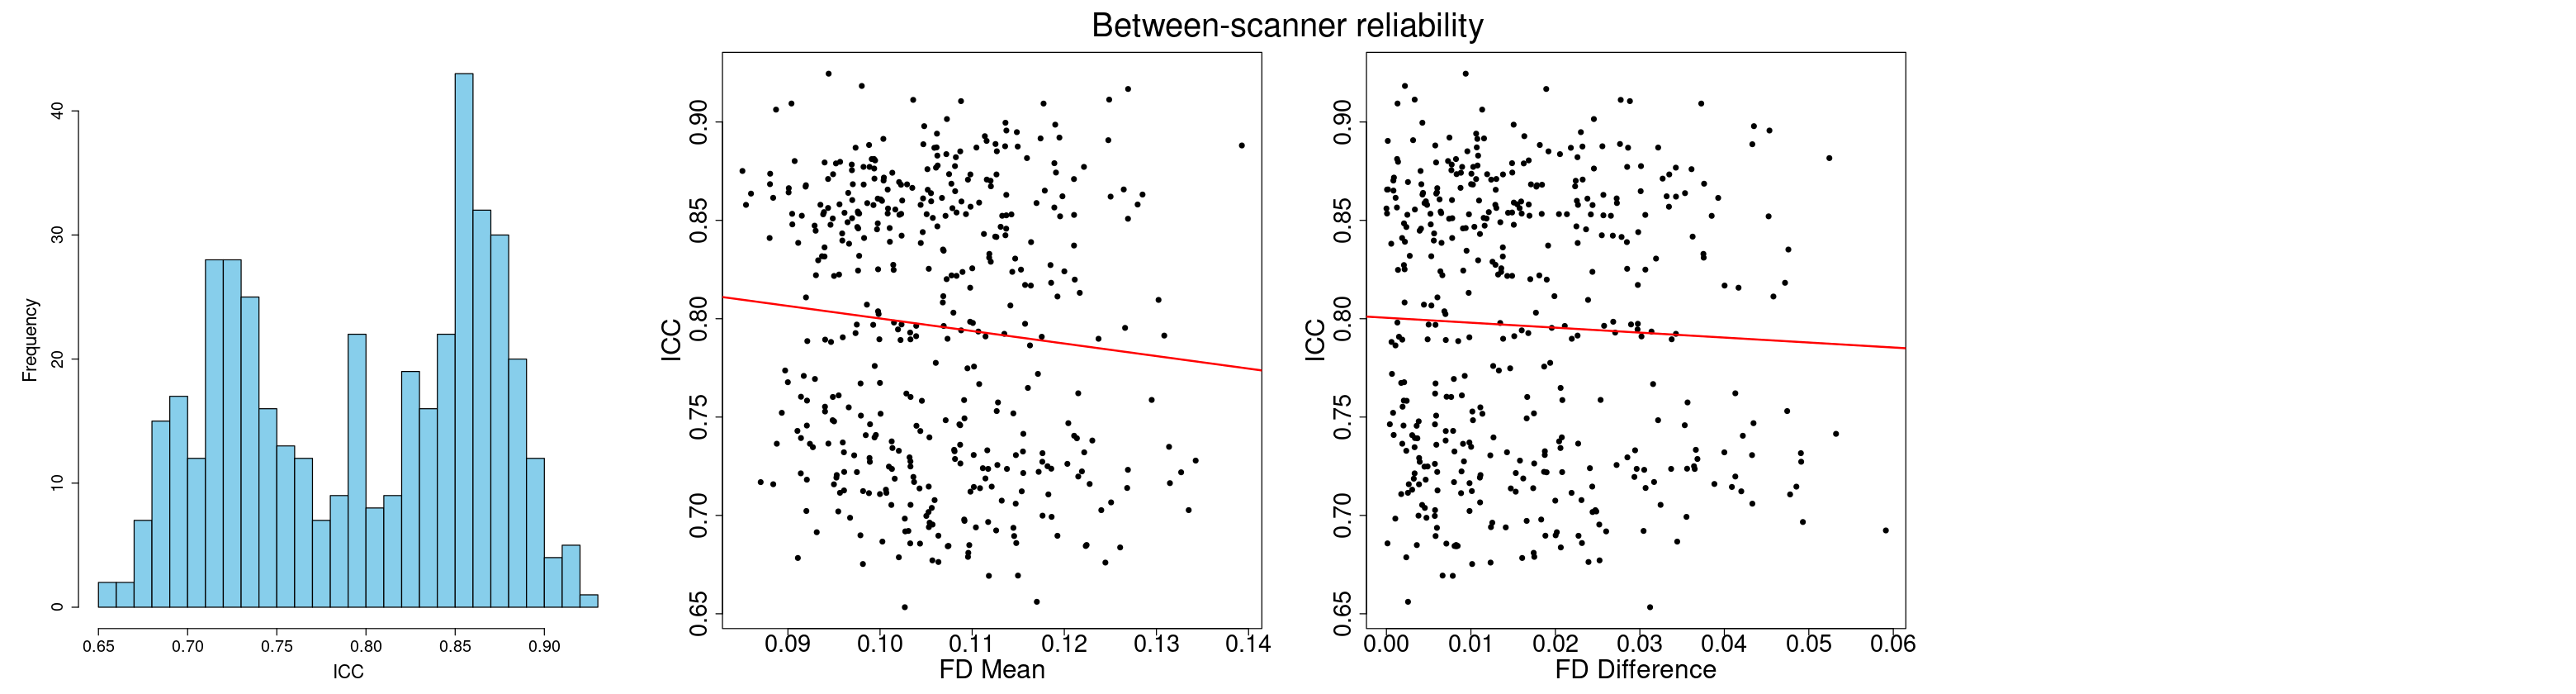

In [15]:
options(repr.plot.width = 26, repr.plot.height = 7)
par(mfrow = c(1, 4), cex.axis = 2, cex.lab = 2, cex.main = 2, cex.sub = 2, mar = c(5, 6, 4, 2))  # Increase left margin

hist(
    icc_between$ICC,
    breaks = 30,
    main = "",
    xlab = "ICC",
    ylab = "Frequency",
    col = "skyblue",
    cex.axis = 1.5,
    cex.lab = 1.7,
    cex.main = 2
)
# Plot ICC vs FD mean
plot(
    icc_between$fd_mean, icc_between$ICC,
    xlab = "FD Mean",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ fd_mean, data = icc_between), col = "red", lwd = 2)

# Plot ICC vs FD diff
plot(
    icc_between$fd_diff, icc_between$ICC,
    xlab = "FD Difference",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ fd_diff, data = icc_between), col = "red", lwd = 2)
mtext("Between-scanner reliability", outer = TRUE, line = -3, cex = 2)
par(mfrow = c(1, 1))  # Reset plotting area

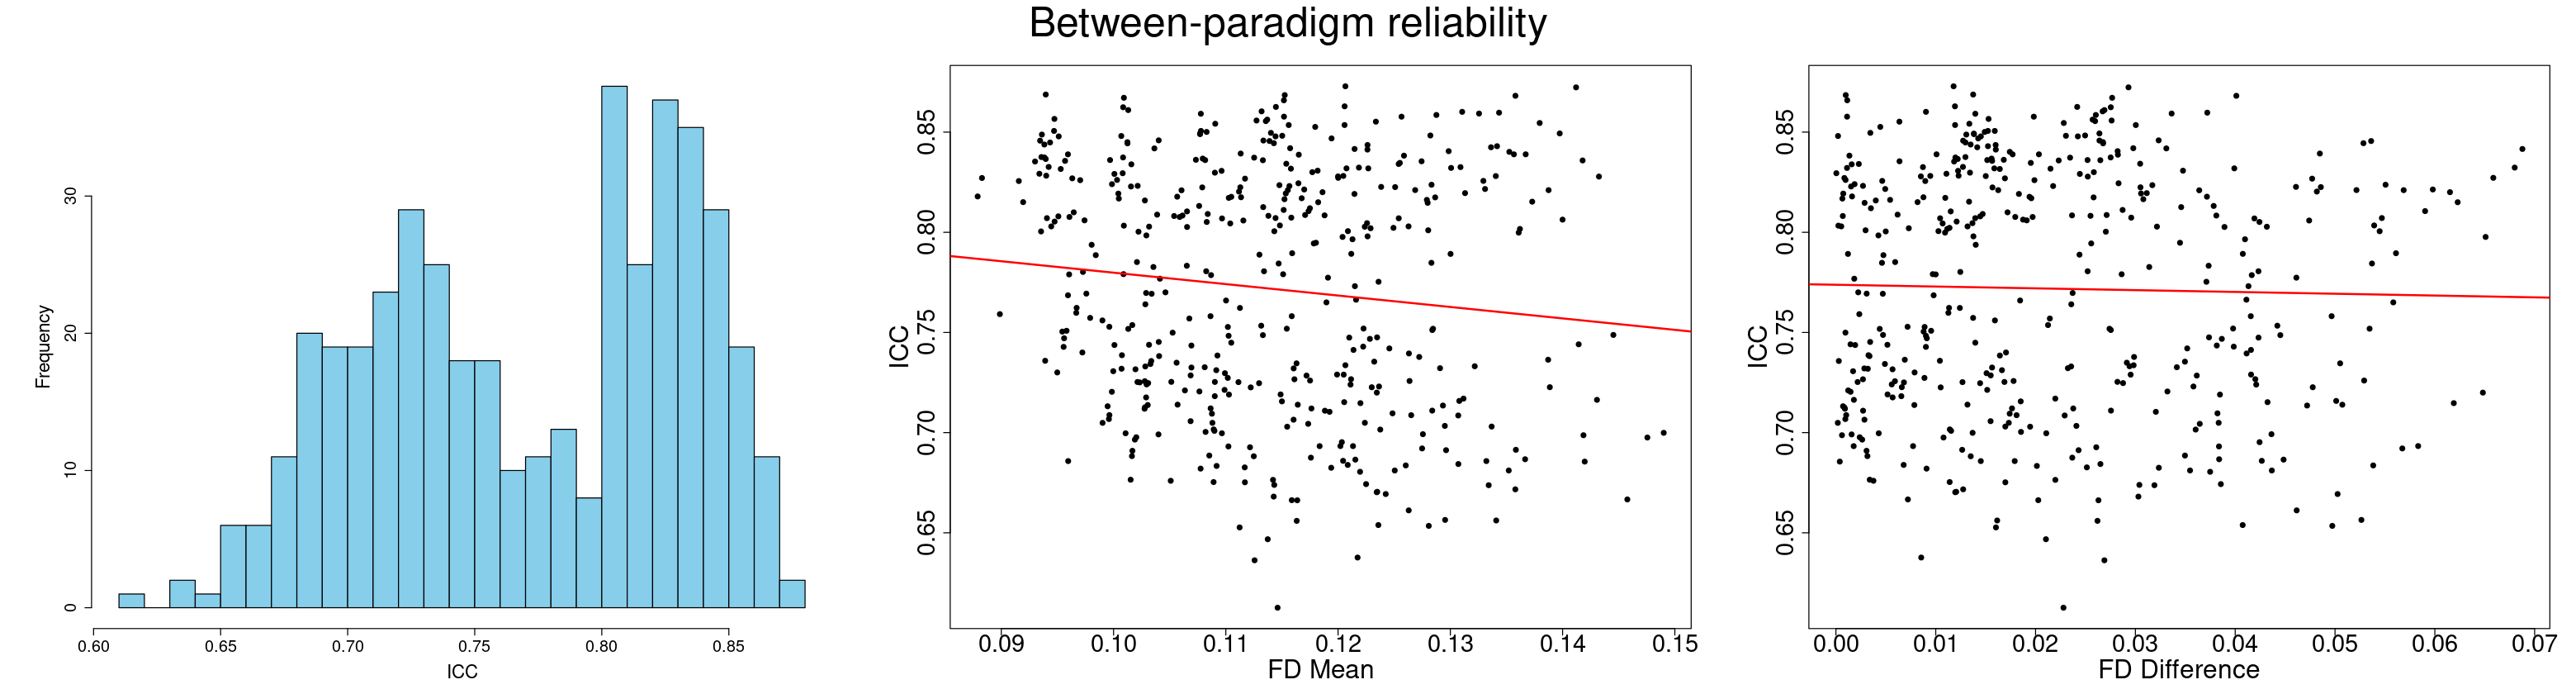

In [16]:
options(repr.plot.width = 26, repr.plot.height = 7)
par(mfrow = c(1, 3), cex.axis = 2.2, cex.lab = 2.4, cex.main = 2.5, cex.sub = 2.2, mar = c(5, 7, 5, 2))  # Further increase font sizes
hist(
    icc_paradigm$ICC,
    breaks = 30,
    main = "",
    xlab = "ICC",
    ylab = "Frequency",
    col = "skyblue",
    cex.axis = 1.5,
    cex.lab = 1.7,
    cex.main = 2
)
# Plot ICC vs FD mean
plot(
    icc_paradigm$fd_mean, icc_paradigm$ICC,
    xlab = "FD Mean",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ fd_mean, data = icc_paradigm), col = "red", lwd = 2)

# Plot ICC vs FD diff
plot(
    icc_paradigm$fd_diff, icc_paradigm$ICC,
    xlab = "FD Difference",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ fd_diff, data = icc_paradigm), col = "red", lwd = 2)
mtext("Between-paradigm reliability", outer = TRUE, line = -3, cex = 2.5)
par(mfrow = c(1, 1))  # Reset plotting area

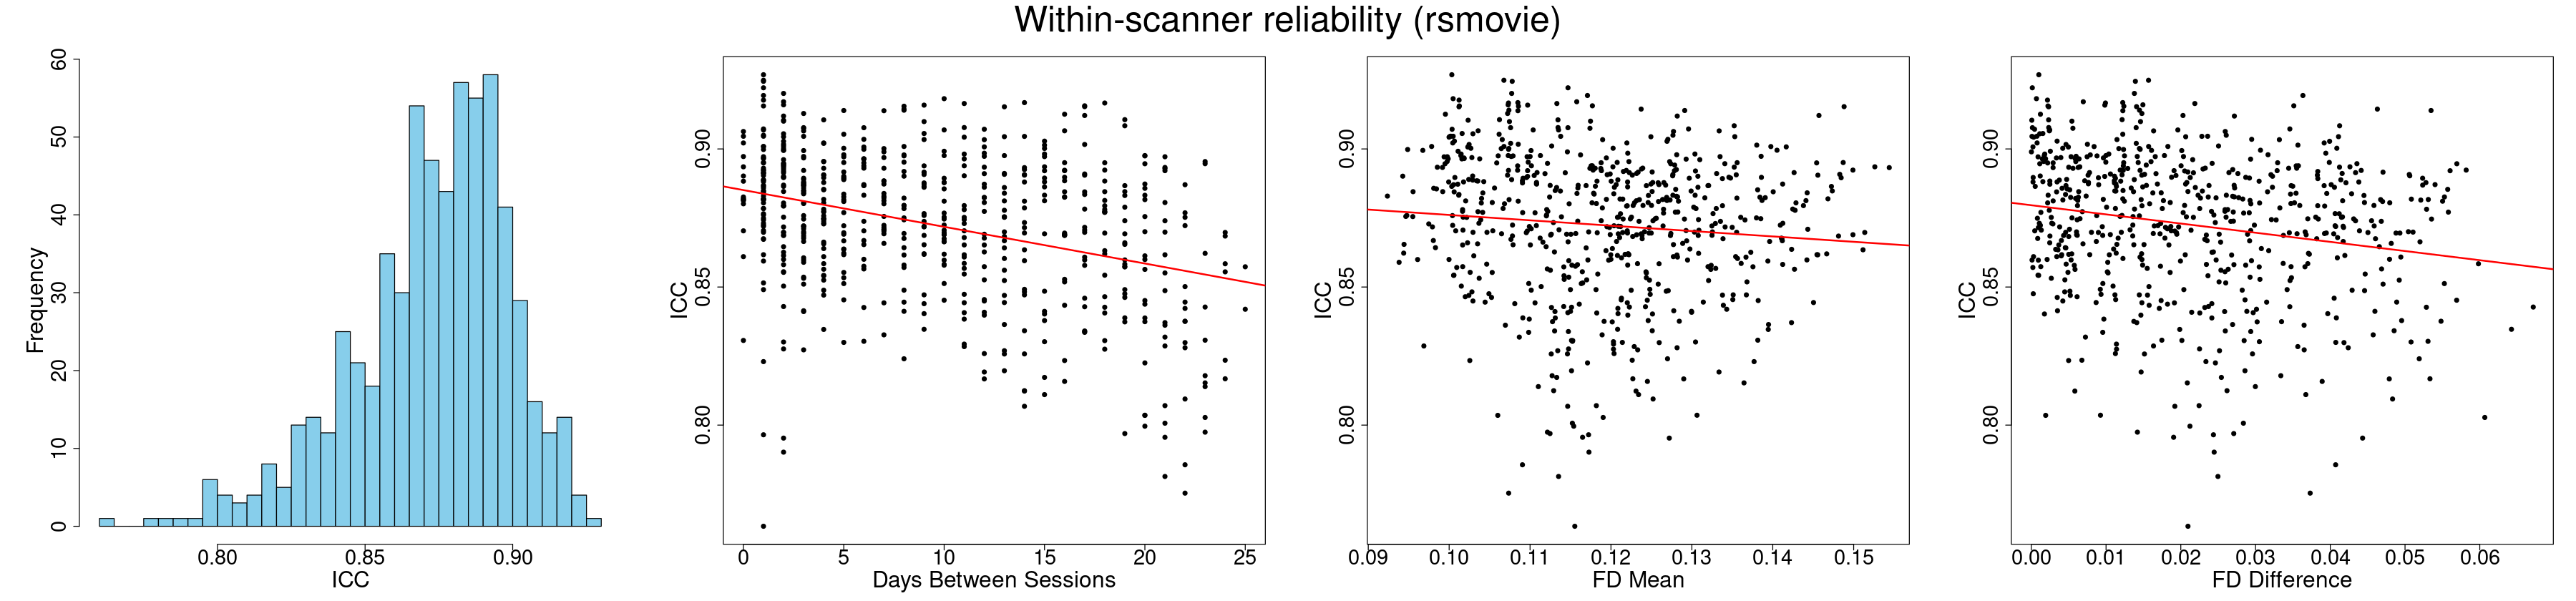

In [17]:
# Make the plot wider by increasing the width of the plotting window and font sizes
options(repr.plot.width = 30, repr.plot.height = 7)
par(mfrow = c(1, 4), cex.axis = 2.2, cex.lab = 2.4, cex.main = 2.5, cex.sub = 2.2, mar = c(5, 7, 5, 2))  # Further increase font sizes
hist(
    icc_intra_rsmovie$ICC,
    breaks = 30,
    main = "",
    xlab = "ICC",
    col = "skyblue",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
plot(
    icc_intra_rsmovie$days_diff, icc_intra_rsmovie$ICC,
    xlab = "Days Between Sessions",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ days_diff, data = icc_intra_rsmovie), col = "red", lwd = 2)

# Plot ICC vs FD mean
plot(
    icc_intra_rsmovie$fd_mean, icc_intra_rsmovie$ICC,
    xlab = "FD Mean",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ fd_mean, data = icc_intra_rsmovie), col = "red", lwd = 2)

# Plot ICC vs FD diff
plot(
    icc_intra_rsmovie$fd_diff, icc_intra_rsmovie$ICC,
    xlab = "FD Difference",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ fd_diff, data = icc_intra_rsmovie), col = "red", lwd = 2)
mtext("Within-scanner reliability (rsmovie)", outer = TRUE, line = -3, cex = 2.5)
par(mfrow = c(1, 1))  # Reset plotting area

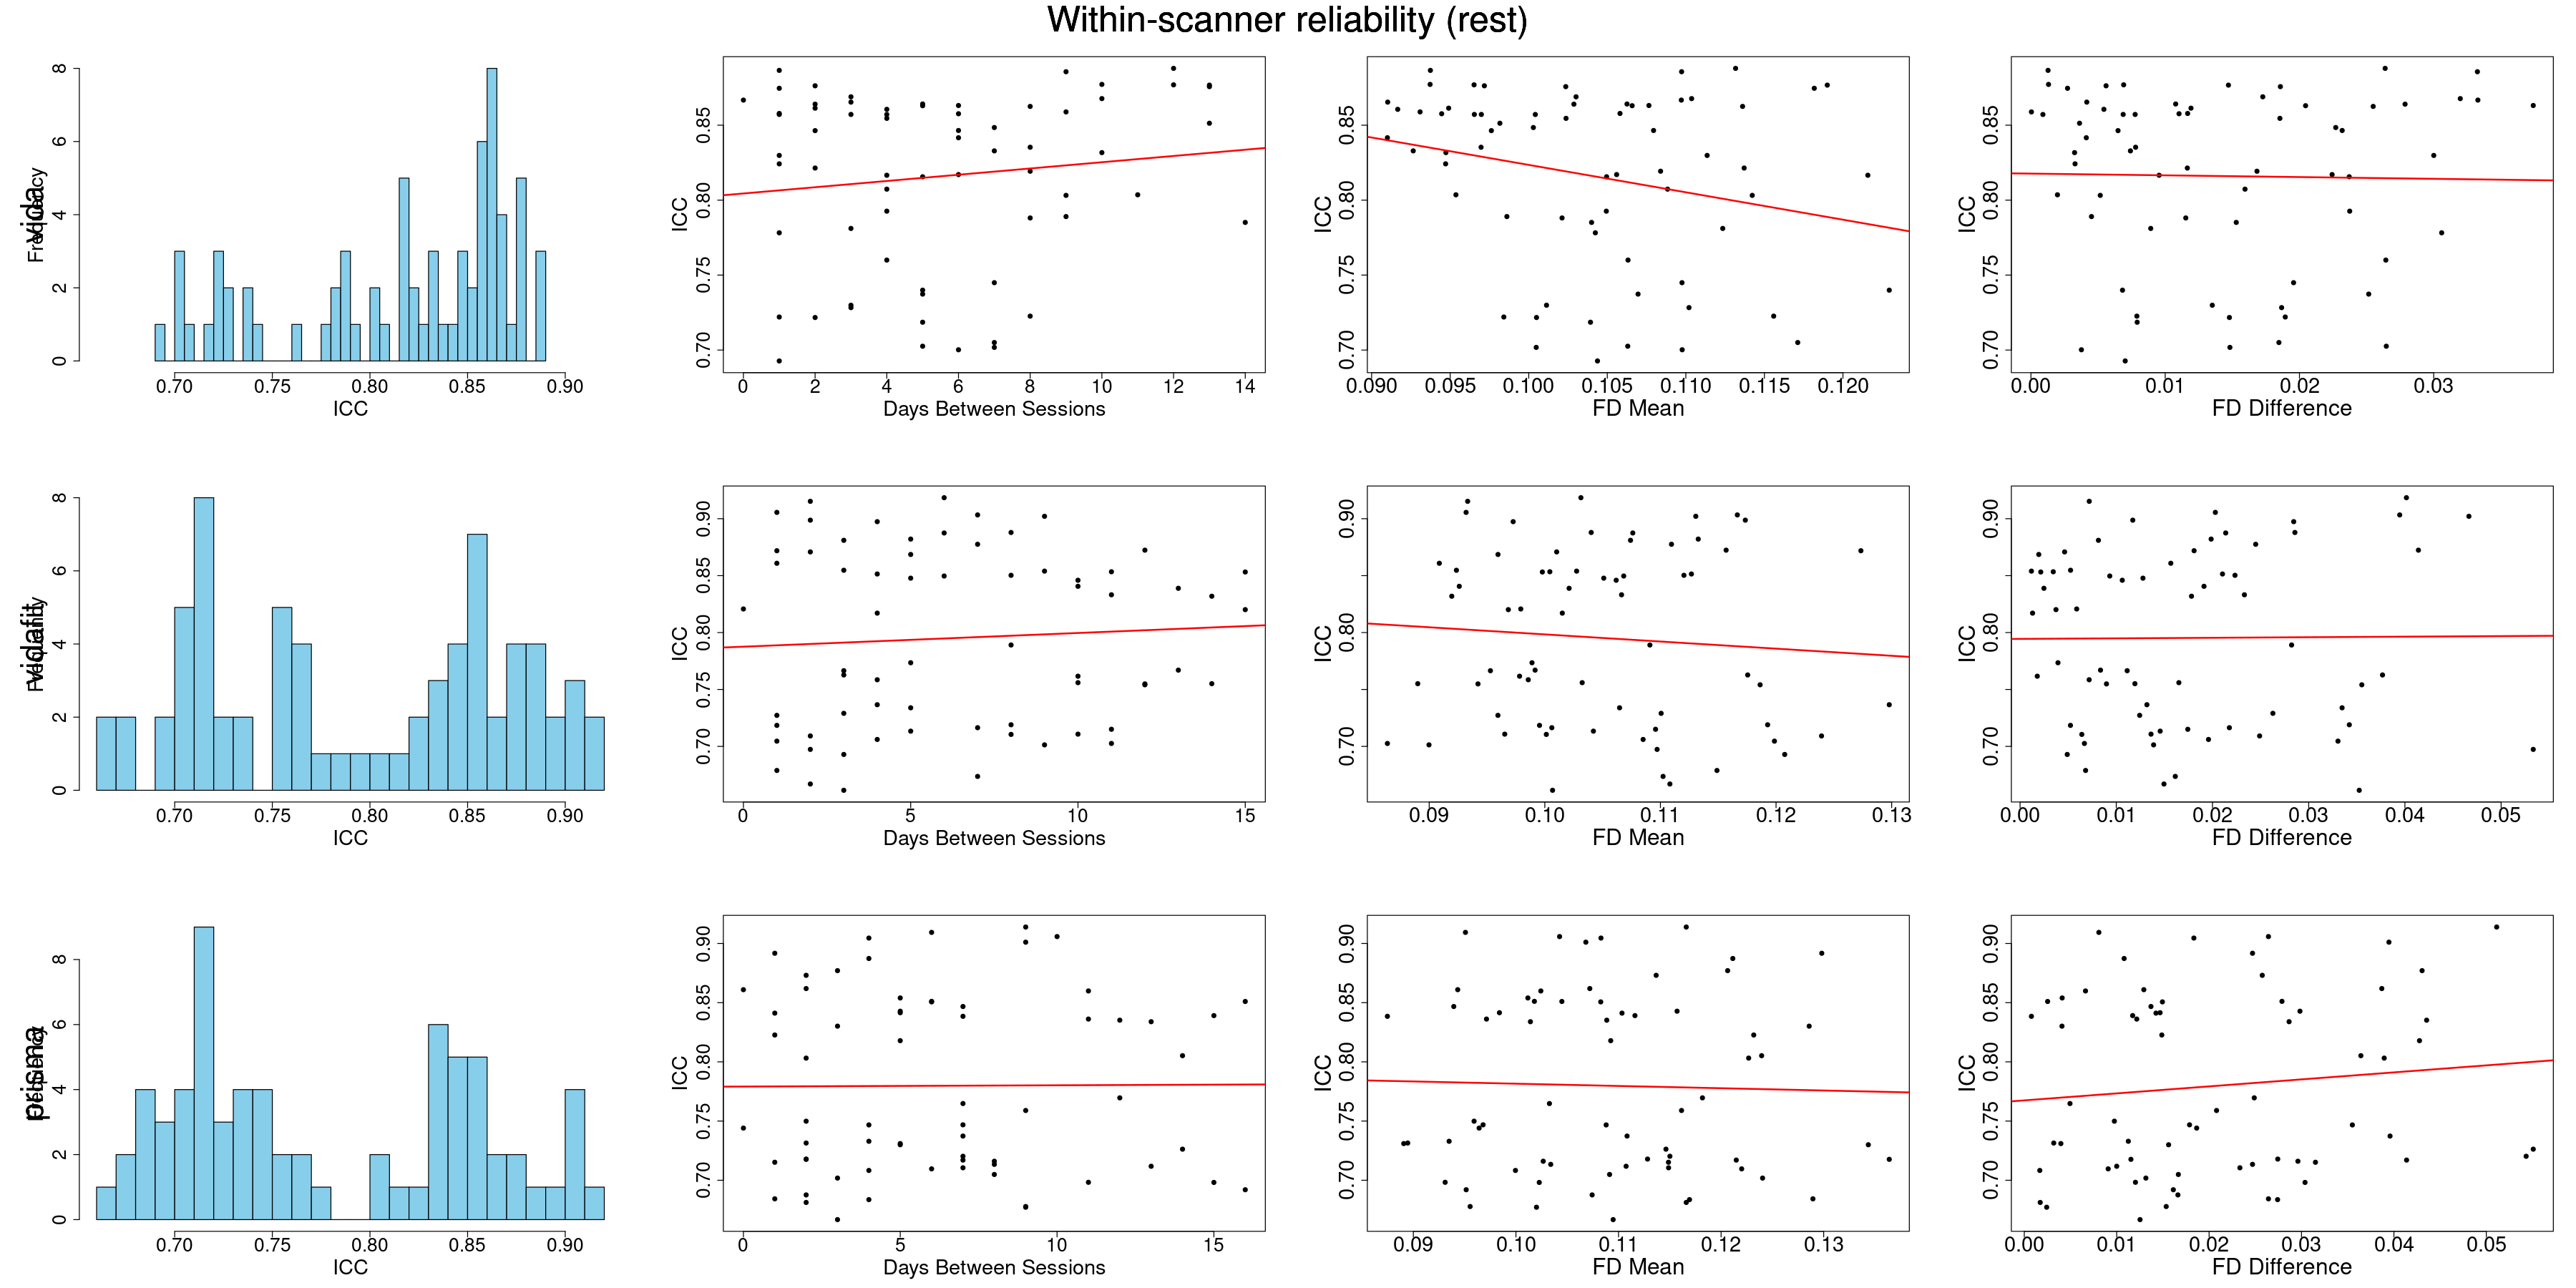

In [18]:
options(repr.plot.width = 30, repr.plot.height = 15)
par(mfrow = c(3, 4), cex.axis = 2, cex.lab = 2.2, cex.main = 2.5, cex.sub = 2, mar = c(5, 7, 5, 2))  # Increase font sizes and margins

# Determine global x-axis limits for ICC
icc_range <- range(icc_intra_rest$ICC, na.rm = TRUE)

for (scanner in c("vida", "vidafit", "prisma")) {
    icc_intra_rest_scanner <- icc_intra_rest[icc_intra_rest$scanner == scanner, ]
    mean_icc <- mean(icc_intra_rest_scanner$ICC, na.rm = TRUE)
    quantiles <- quantile(icc_intra_rest_scanner$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)   
    # Histogram with fixed xlim
    hist(
        icc_intra_rest_scanner$ICC,
        breaks = 30,
        xlab = "ICC",
        main = '',
        col = "skyblue",
        cex.axis = 2,
        cex.lab = 2.2,
        xlim = icc_range
    )
    mtext(scanner, side = 2, line = 3, cex = 2.2, las = 0)
    # Scatter plot: ICC vs days_diff
    plot(
        icc_intra_rest_scanner$days_diff, icc_intra_rest_scanner$ICC,
        xlab = "Days Between Sessions",
        ylab = "ICC",
        pch = 19,
        cex.axis = 2,
        cex.lab = 2.2
    )
    abline(lm(ICC ~ days_diff, data = icc_intra_rest_scanner), col = "red", lwd = 2)
    # Plot ICC vs FD mean
    plot(
        icc_intra_rest_scanner$fd_mean, icc_intra_rest_scanner$ICC,
        xlab = "FD Mean",
        ylab = "ICC",
        main = "",
        pch = 19,
        cex.axis = 2.2,
        cex.lab = 2.4,
        cex.main = 2.5
    )
    abline(lm(ICC ~ fd_mean, data = icc_intra_rest_scanner), col = "red", lwd = 2)

    # Plot ICC vs FD diff
    plot(
        icc_intra_rest_scanner$fd_diff, icc_intra_rest_scanner$ICC,
        xlab = "FD Difference",
        ylab = "ICC",
        main = "",
        pch = 19,
        cex.axis = 2.2,
        cex.lab = 2.4,
        cex.main = 2.5
    )
    abline(lm(ICC ~ fd_diff, data = icc_intra_rest_scanner), col = "red", lwd = 2)
    mtext("Within-scanner reliability (rest)", outer = TRUE, line = -3, cex = 2.5)
}
par(mfrow = c(1, 1))  # Reset plotting area